<a href="https://colab.research.google.com/github/gabrieladamasceno/ZERO-DAY-ATTACK-DETECTION-6G/blob/main/Heatmaps/Heatmap_Dataset_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io

In [2]:
df_test = '''
Model,Ataque Zero-Day,Accuracy,F1,Precision,Recall,Time,CPU,Memory,Energy,ZD - Accuracy,ZD - F1,ZD - Precision,ZD - Recall,ZD - Time,ZD - CPU,ZD - Memory,ZD - Energy
Decision Tree,ICMPFlood,0.999502,0.99959,0.999559,0.99962,1.13576,1.47273,3152.91,2.90231e-05,1.0,1.0,1,1.0,1.11197,0.781818,3155.88,4.2511e-06
Decision Tree,UDPFlood,0.623819,0.550262,0.998965,0.379709,1.13215,0.781818,2993.85,4.32822e-06,0.0,0.0,1,0.0,1.11886,7.72727,2994.2,0.00412994
Decision Tree,SYNFlood,0.996973,0.997498,0.999557,0.995447,1.13525,0.672727,3422.34,2.76503e-06,0.679521,0.809184,1,0.679521,1.11178,1.13636,3422.36,1.30516e-05
Decision Tree,SYNScan,0.99949,0.999579,0.999552,0.999606,1.13532,1.03636,3339.82,1.01099e-05,1.0,1.0,1,1.0,1.11226,0.9,3339.82,6.48668e-06
Decision Tree,HTTPFlood,0.987429,0.989525,0.999592,0.979659,1.13552,0.809091,3264.67,4.81147e-06,0.895501,0.94487,1,0.895501,1.11533,0.463636,3264.67,8.89258e-07
Decision Tree,UDPScan,0.999502,0.99959,0.999559,0.99962,1.13639,2.61818,3255.81,0.000163161,1.0,1.0,1,1.0,1.11261,2.95455,3255.81,0.000229565
Decision Tree,TCPConnectScan,0.984205,0.986798,0.999951,0.973986,1.13489,0.790909,3335.09,4.49184e-06,0.0676042,0.126647,1,0.0676042,1.11256,0.790909,3335.09,4.40344e-06
Decision Tree,SlowrateDoS,0.99949,0.999579,0.999539,0.99962,1.13453,0.572727,3324.33,1.7051e-06,1.0,1.0,1,1.0,1.11319,1.01818,3324.33,9.40013e-06
Random Forest,ICMPFlood,0.999761,0.999803,0.99998,0.999627,2.55988,1.12727,3120.73,2.93357e-05,1.0,1.0,1,1.0,1.19521,0.781818,3123.7,4.56933e-06
Random Forest,UDPFlood,0.626928,0.555382,0.999982,0.384452,2.2913,0.563636,3010.02,3.28222e-06,0.00764595,0.0151759,1,0.00764595,1.55178,1.00909,3010.04,1.27559e-05
Random Forest,SYNFlood,0.997232,0.997712,0.99998,0.995454,2.55693,0.563636,3422.0,3.66273e-06,0.679521,0.809184,1,0.679521,1.21053,1.12727,3422.0,1.38724e-05
Random Forest,SYNScan,0.999757,0.9998,0.99998,0.99962,2.50366,0.563636,3329.74,3.58643e-06,1.0,1.0,1,1.0,1.21325,0.681818,3329.74,3.07641e-06
Random Forest,HTTPFlood,0.963282,0.968763,0.999978,0.939437,2.49788,5.96364,3254.35,0.00423834,0.685012,0.813065,1,0.685012,1.33202,0.681818,3254.35,3.37757e-06
Random Forest,UDPScan,0.999544,0.999623,0.99998,0.999267,2.47079,2.24545,3329.06,0.000223789,0.983401,0.991631,1,0.983401,1.21495,15.0273,3329.06,0.0329828
Random Forest,TCPConnectScan,0.983181,0.98593,0.999986,0.972263,2.41325,12.1,3325.68,0.0342018,0.00493462,0.00982077,1,0.00493462,1.2189,0.681818,3325.68,3.09076e-06
Random Forest,SlowrateDoS,0.999704,0.999756,0.999973,0.999539,2.51673,11.2455,3330.22,0.0286324,0.999173,0.999586,1,0.999173,1.26157,1.01818,3330.22,1.06532e-05
Catboost,ICMPFlood,0.9997,0.999752,0.999986,0.999518,3.59186,11.4364,3428.5,0.0429806,1.0,1.0,1,1.0,1.1233,1.33636,3363.05,2.14467e-05
Catboost,UDPFlood,0.624045,0.550406,0.999964,0.379702,3.43208,4.09091,3253.06,0.00187978,0.0,0.0,1,0.0,2.0261,11.1455,3208.15,0.0224411
Catboost,SYNFlood,0.997216,0.997698,0.99998,0.995427,3.47597,10.4545,3739.56,0.0317747,0.679521,0.809184,1,0.679521,1.14063,0.790909,3677.11,4.51454e-06
Catboost,SYNScan,0.999724,0.999773,0.999973,0.999573,3.4588,0.563636,3691.31,4.95464e-06,0.998973,0.999486,1,0.998973,1.16273,0.672727,3637.44,2.83196e-06
Catboost,HTTPFlood,0.999692,0.999746,0.999986,0.999505,3.41051,2.94545,3546.25,0.000697215,1.0,1.0,1,1.0,1.43283,14.9727,3497.13,0.0384759
Catboost,UDPScan,0.999523,0.999606,0.999973,0.99924,3.46373,8.37273,3622.46,0.0162643,0.983401,0.991631,1,0.983401,1.15318,0.990909,3564.37,8.97608e-06
Catboost,TCPConnectScan,0.998137,0.998461,0.999993,0.996933,3.43445,1.35455,3707.27,6.82854e-05,0.903035,0.949047,1,0.903035,1.16323,1.23636,3632.78,1.75871e-05
Catboost,SlowrateDoS,0.999745,0.99979,0.99998,0.9996,3.44284,1.36364,3578.06,6.98398e-05,1.0,1.0,1,1.0,1.26872,1.91818,3520.78,7.16348e-05
MLP,ICMPFlood,0.997492,0.997927,0.999721,0.996139,9.55611,3.29091,3283.37,0.0027247,0.0,0.0,1,0.0,1.78034,4.56364,3244.33,0.00135371
MLP,UDPFlood,0.623741,0.550184,0.998733,0.379668,10.03,1.8,3222.18,0.000467958,0.0,0.0,1,0.0,4.77848,3.01818,3231.51,0.00105103
MLP,SYNFlood,0.996636,0.99723,0.995557,0.998908,10.3845,2.28182,3657.51,0.000987005,0.999479,0.999739,1,0.999479,1.8722,6.99091,3352.99,0.00511733
MLP,SYNScan,0.997467,0.997908,0.998885,0.996933,10.0483,2.50909,3506.02,0.00126979,0.998716,0.999358,1,0.998716,1.97716,0.790909,3506.15,7.8255e-06
MLP,HTTPFlood,0.916205,0.925905,0.997571,0.863845,10.1999,1.90909,3443.63,0.000567762,0.301069,0.462802,1,0.301069,2.80644,7.18182,3313.47,0.00831667
MLP,UDPScan,0.998524,0.998782,0.998664,0.998901,9.85383,2.4,3534.12,0.00108975,0.99906,0.99953,1,0.99906,1.88766,2.98182,3534.95,0.000400367
MLP,TCPConnectScan,0.99722,0.997708,0.997342,0.998073,9.90925,3.1,3574.23,0.00236165,0.977301,0.98852,1,0.977301,1.95573,0.9,3453.97,1.14058e-05
MLP,SlowrateDoS,0.968961,0.973774,0.997928,0.950761,9.80359,3.42727,3527.18,0.00315734,0.526857,0.690119,1,0.526857,2.29626,0.918182,3528.03,1.42199e-05
Autoencoder,ICMPFlood,0.494268,0.447166,0.662511,0.337472,8.85588,3.19091,3228.06,0.00230179,1.0,1.0,1,1.0,1.86609,1.58182,3318.06,5.9087e-05
Autoencoder,UDPFlood,0.326987,0.159613,0.328153,0.105452,9.10445,2.97273,2969.87,0.00191341,0.000557859,0.0011151,1,0.000557859,4.51718,1.13636,2959.19,5.30285e-05
Autoencoder,SYNFlood,0.492906,0.446978,0.659197,0.338124,9.99661,1.83636,3334.31,0.000495243,0.863992,0.927034,1,0.863992,2.01792,3.32727,3301.52,0.000594647
Autoencoder,SYNScan,0.490053,0.445522,0.653257,0.338029,9.59136,1.47273,3345.63,0.000245096,0.84566,0.916377,1,0.84566,2.10951,8.1,3292.83,0.00896862
Autoencoder,HTTPFlood,0.478904,0.467958,0.613805,0.378114,9.27195,2.3,3261.9,0.000902495,1.0,1.0,1,1.0,2.85076,0.545455,3145.82,3.70106e-06
Autoencoder,UDPScan,0.490205,0.445397,0.653736,0.337757,10.3073,2.83636,3497.23,0.00188156,0.89477,0.944463,1,0.89477,2.02821,0.9,3460.66,1.18285e-05
Autoencoder,TCPConnectScan,0.497701,0.448278,0.67049,0.336692,9.78543,2.47273,3509.46,0.00118358,0.0276339,0.0537815,1,0.0276339,2.08884,0.672727,3475.33,5.08759e-06
Autoencoder,SlowrateDoS,0.476918,0.445835,0.62283,0.347175,9.80581,0.909091,3379.24,5.8938e-05,1.0,1.0,1,1.0,2.47243,4.69091,3416.95,0.00204167
'''

In [3]:
df = pd.read_csv(io.StringIO(df_test))

print("DataFrame")
print(df.head())

DataFrame
           Model Ataque Zero-Day  Accuracy        F1  Precision    Recall  \
0  Decision Tree       ICMPFlood  0.999502  0.999590   0.999559  0.999620   
1  Decision Tree        UDPFlood  0.623819  0.550262   0.998965  0.379709   
2  Decision Tree        SYNFlood  0.996973  0.997498   0.999557  0.995447   
3  Decision Tree         SYNScan  0.999490  0.999579   0.999552  0.999606   
4  Decision Tree       HTTPFlood  0.987429  0.989525   0.999592  0.979659   

      Time       CPU   Memory    Energy  ZD - Accuracy   ZD - F1  \
0  1.13576  1.472730  3152.91  0.000029       1.000000  1.000000   
1  1.13215  0.781818  2993.85  0.000004       0.000000  0.000000   
2  1.13525  0.672727  3422.34  0.000003       0.679521  0.809184   
3  1.13532  1.036360  3339.82  0.000010       1.000000  1.000000   
4  1.13552  0.809091  3264.67  0.000005       0.895501  0.944870   

   ZD - Precision  ZD - Recall  ZD - Time  ZD - CPU  ZD - Memory   ZD - Energy  
0               1     1.000000    1.1

In [4]:
attack_mapping = {
    'ICMPFlood': 'ICMP Flood',
    'UDPFlood': 'UDP Flood',
    'SYNFlood': 'SYN Flood',
    'SYNScan': 'SYN Scan',
    'HTTPFlood': 'HTTP Flood',
    'UDPScan': 'UDP Scan',
    'TCPConnectScan': 'TCP Connect Scan',
    'SlowrateDoS': 'Slow Rate DoS'
}

df['Ataque Zero-Day'] = df['Ataque Zero-Day'].map(attack_mapping)

In [5]:
data_for_heatmap = df[['Model', 'Ataque Zero-Day', 'Accuracy', 'ZD - Accuracy']]
data_for_heatmap = data_for_heatmap.rename(columns={'ZD - Accuracy': 'Accuracy Zero-Day', 'Ataque Zero-Day': 'Attack Zero-Day'})

In [6]:
df_melted = data_for_heatmap.melt(
    id_vars=['Model', 'Attack Zero-Day'],
    value_vars=['Accuracy', 'Accuracy Zero-Day'],
    var_name='Scenario',
    value_name='Accuracy Value'
)

df_pivot = df_melted.pivot_table(
    index='Attack Zero-Day',
    columns=['Model', 'Scenario'],
    values='Accuracy Value'
)


# Metrics

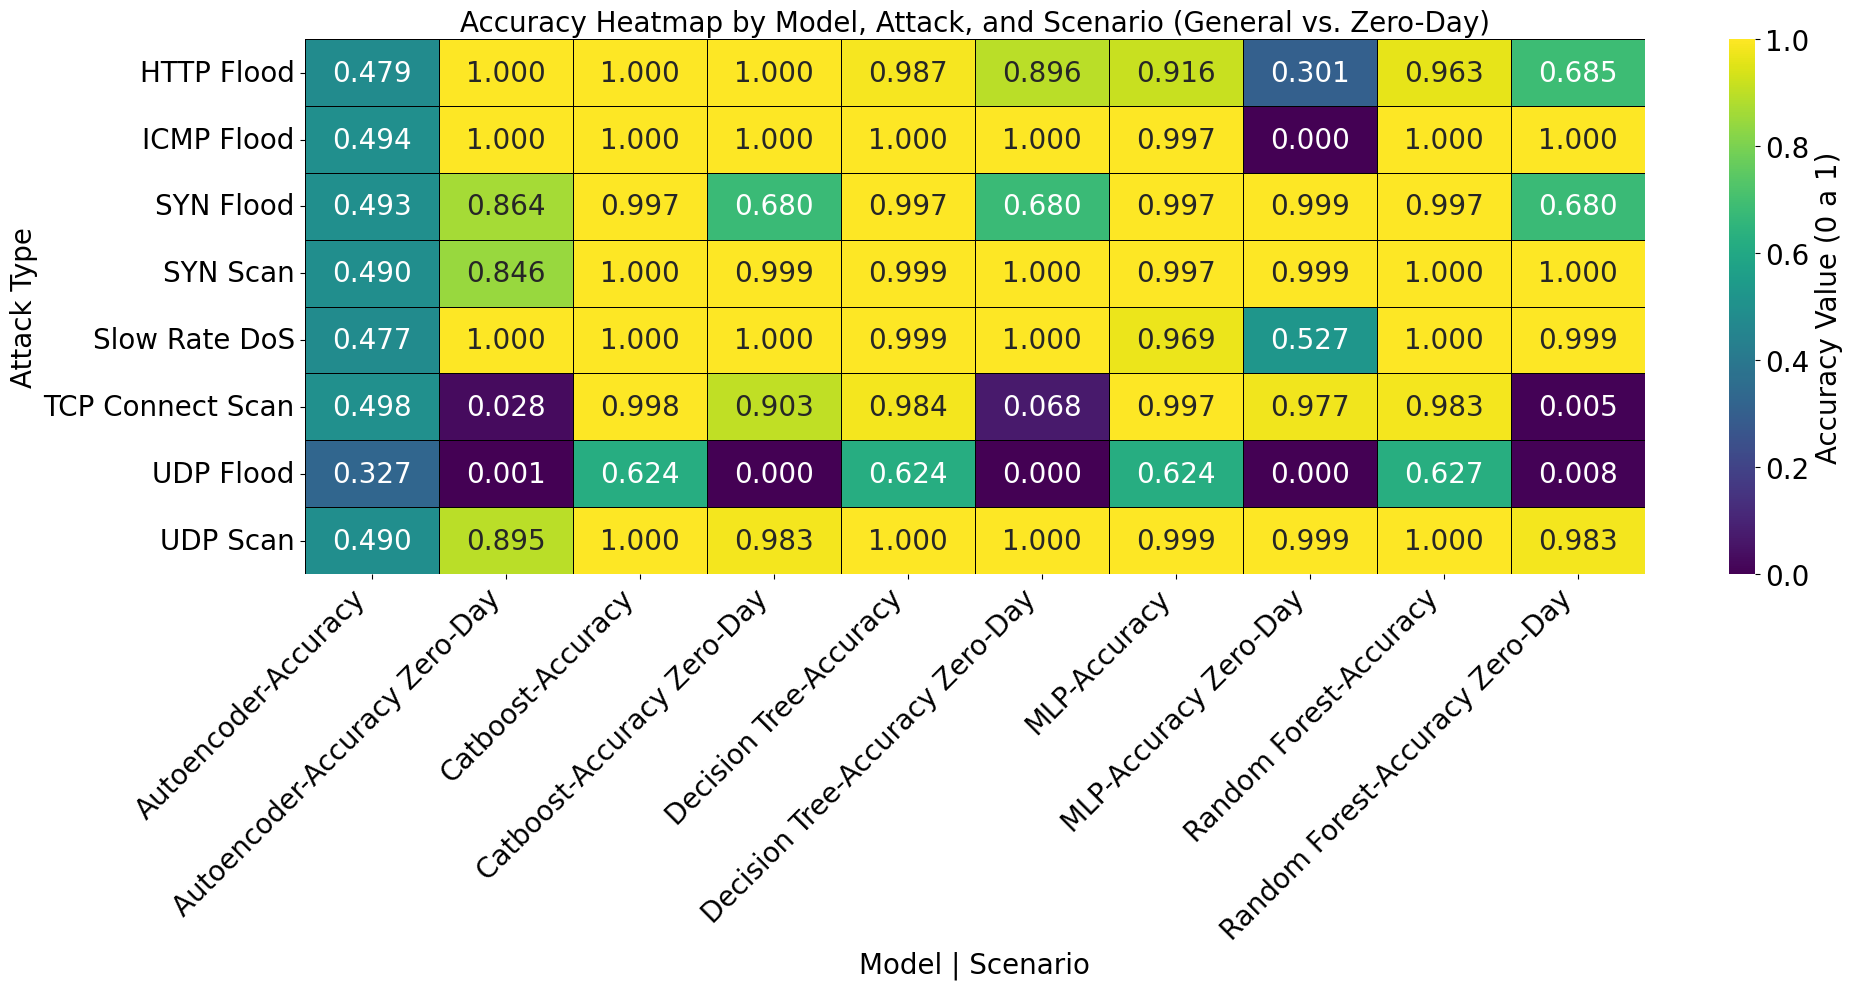

In [7]:
plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    df_pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Accuracy Value (0 a 1)'},
    annot_kws={"fontsize": 20}
)

plt.title('Accuracy Heatmap by Model, Attack, and Scenario (General vs. Zero-Day)', fontsize=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)

plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

cbar = ax.collections[0].colorbar
cbar.set_label('Accuracy Value (0 a 1)', fontsize=20)

cbar.ax.tick_params(labelsize=20)

plt.tight_layout()
plt.show()

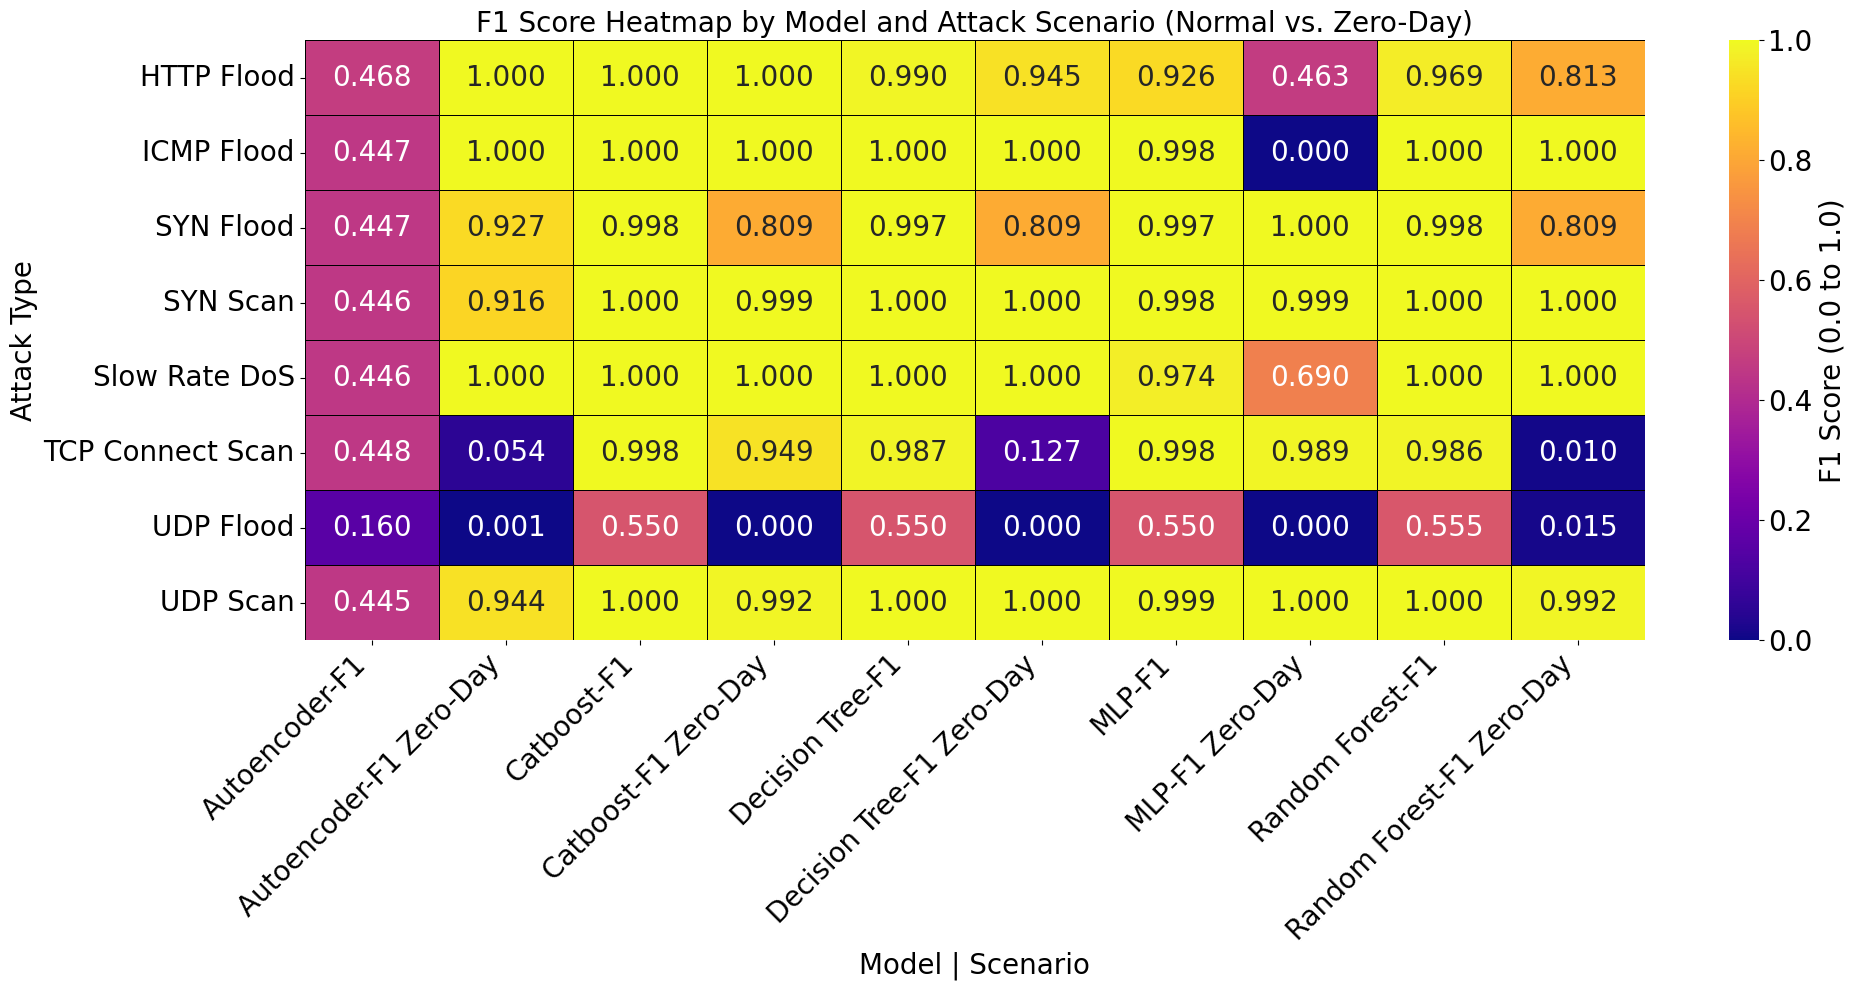

In [8]:
data_f1_heatmap = df[['Model', 'Ataque Zero-Day', 'F1', 'ZD - F1']].rename(columns={
    'Ataque Zero-Day': 'Attack Zero-Day',
    'ZD - F1': 'F1 Zero-Day'
})

df_melted_f1 = data_f1_heatmap.melt(
    id_vars=['Model', 'Attack Zero-Day'],
    value_vars=['F1', 'F1 Zero-Day'],
    var_name='Scenario',
    value_name='F1 Score'
)

df_pivot_f1 = df_melted_f1.pivot_table(
    index='Attack Zero-Day',
    columns=['Model', 'Scenario'],
    values='F1 Score'
)

plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    df_pivot_f1,
    annot=True,
    fmt=".3f",
    cmap="plasma",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'F1 Score (0.0 to 1.0)'},
    annot_kws={"fontsize": 20}
)

plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

cbar = ax.collections[0].colorbar
cbar.set_label('F1 Score (0.0 to 1.0)', fontsize=20)

cbar.ax.tick_params(labelsize=20)

plt.title('F1 Score Heatmap by Model and Attack Scenario (Normal vs. Zero-Day)', fontsize=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

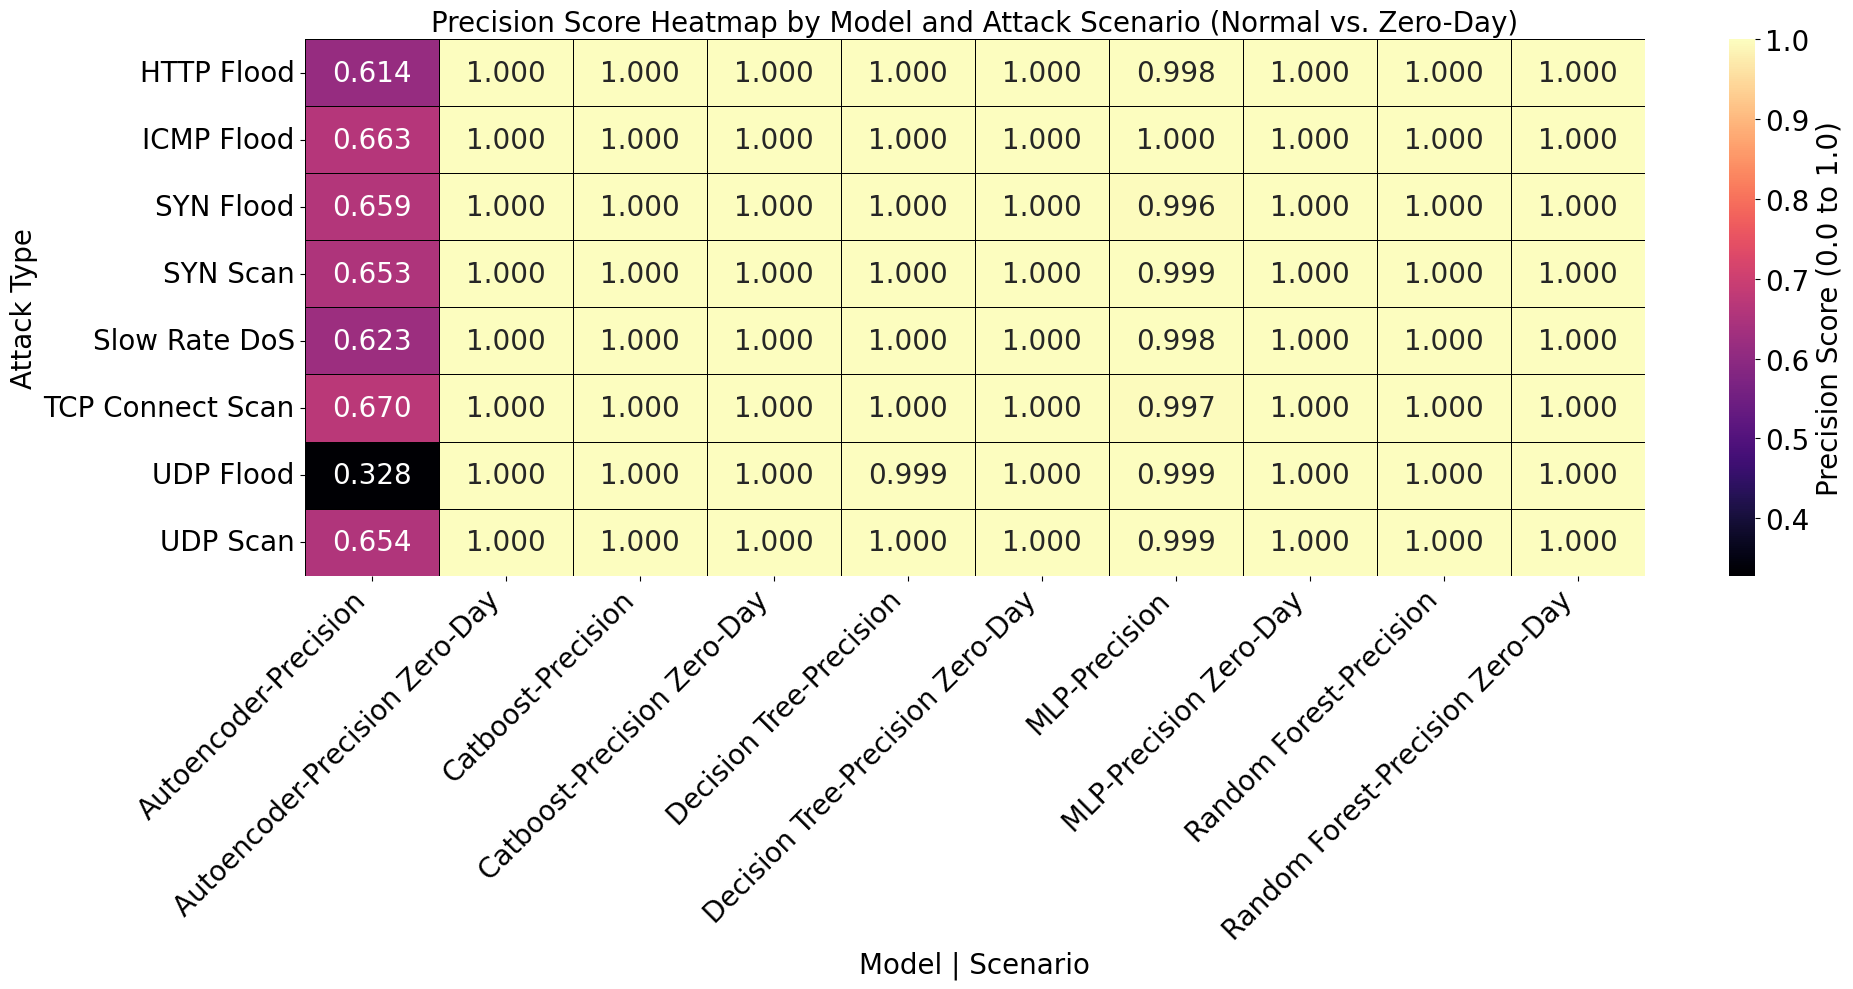

In [9]:
data_precision_heatmap = df[['Model', 'Ataque Zero-Day', 'Precision', 'ZD - Precision']].rename(columns={
    'Ataque Zero-Day': 'Attack Zero-Day',
    'ZD - Precision': 'Precision Zero-Day'
})

df_melted_precision = data_precision_heatmap.melt(
    id_vars=['Model', 'Attack Zero-Day'],
    value_vars=['Precision', 'Precision Zero-Day'],
    var_name='Scenario',
    value_name='Precision Score'
)

df_pivot_precision = df_melted_precision.pivot_table(
    index='Attack Zero-Day',
    columns=['Model', 'Scenario'],
    values='Precision Score'
)

plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    df_pivot_precision,
    annot=True,
    fmt=".3f",
    cmap="magma",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Precision Score (0.0 to 1.0)'},
    annot_kws={"fontsize": 20}
)


plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

cbar = ax.collections[0].colorbar
cbar.set_label('Precision Score (0.0 to 1.0)', fontsize=20)

cbar.ax.tick_params(labelsize=20)


plt.title('Precision Score Heatmap by Model and Attack Scenario (Normal vs. Zero-Day)', fontsize=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

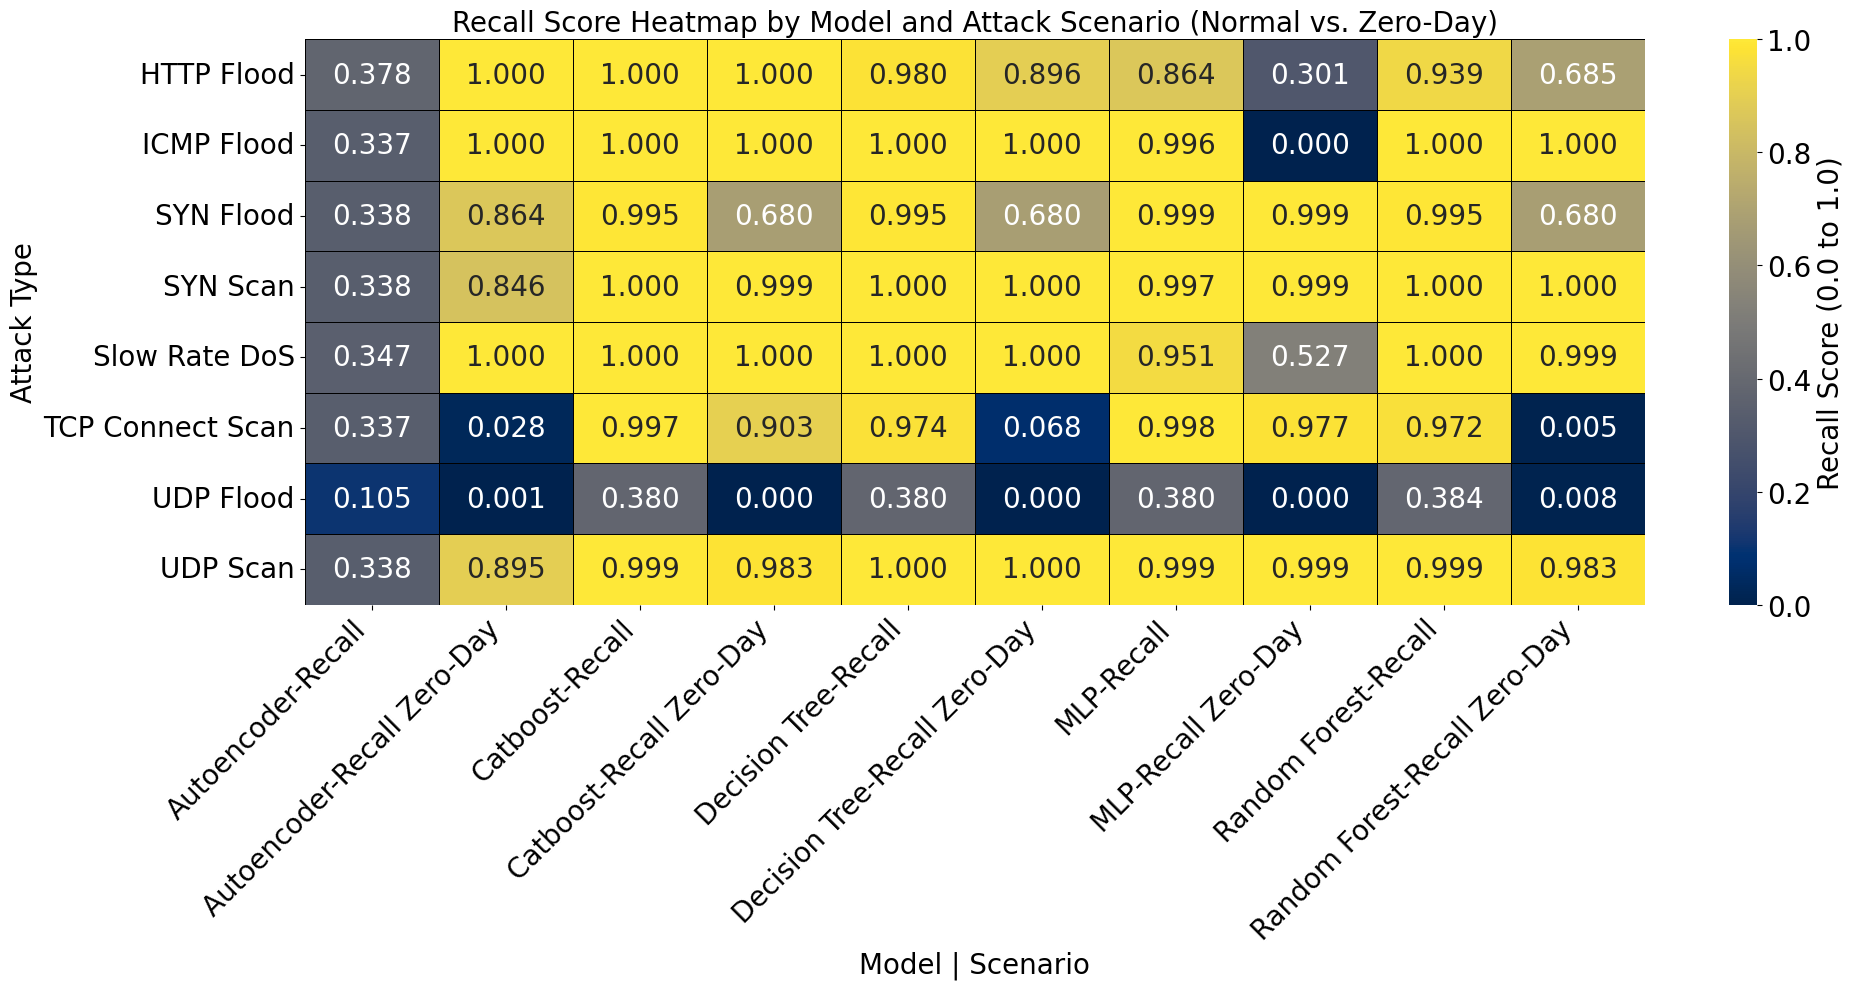

In [10]:
data_recall_heatmap = df[['Model', 'Ataque Zero-Day', 'Recall', 'ZD - Recall']].rename(columns={
    'Ataque Zero-Day': 'Attack Zero-Day',
    'ZD - Recall': 'Recall Zero-Day'
})

df_melted_recall = data_recall_heatmap.melt(
    id_vars=['Model', 'Attack Zero-Day'],
    value_vars=['Recall', 'Recall Zero-Day'],
    var_name='Scenario',
    value_name='Recall Score'
)

df_pivot_recall = df_melted_recall.pivot_table(
    index='Attack Zero-Day',
    columns=['Model', 'Scenario'],
    values='Recall Score'
)

plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    df_pivot_recall,
    annot=True,
    fmt=".3f",
    cmap="cividis",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Recall Score (0.0 to 1.0)'},
    annot_kws={"fontsize": 20}
)

plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

cbar = ax.collections[0].colorbar
cbar.set_label('Recall Score (0.0 to 1.0)', fontsize=20)

cbar.ax.tick_params(labelsize=20)

plt.title('Recall Score Heatmap by Model and Attack Scenario (Normal vs. Zero-Day)', fontsize=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# CPU

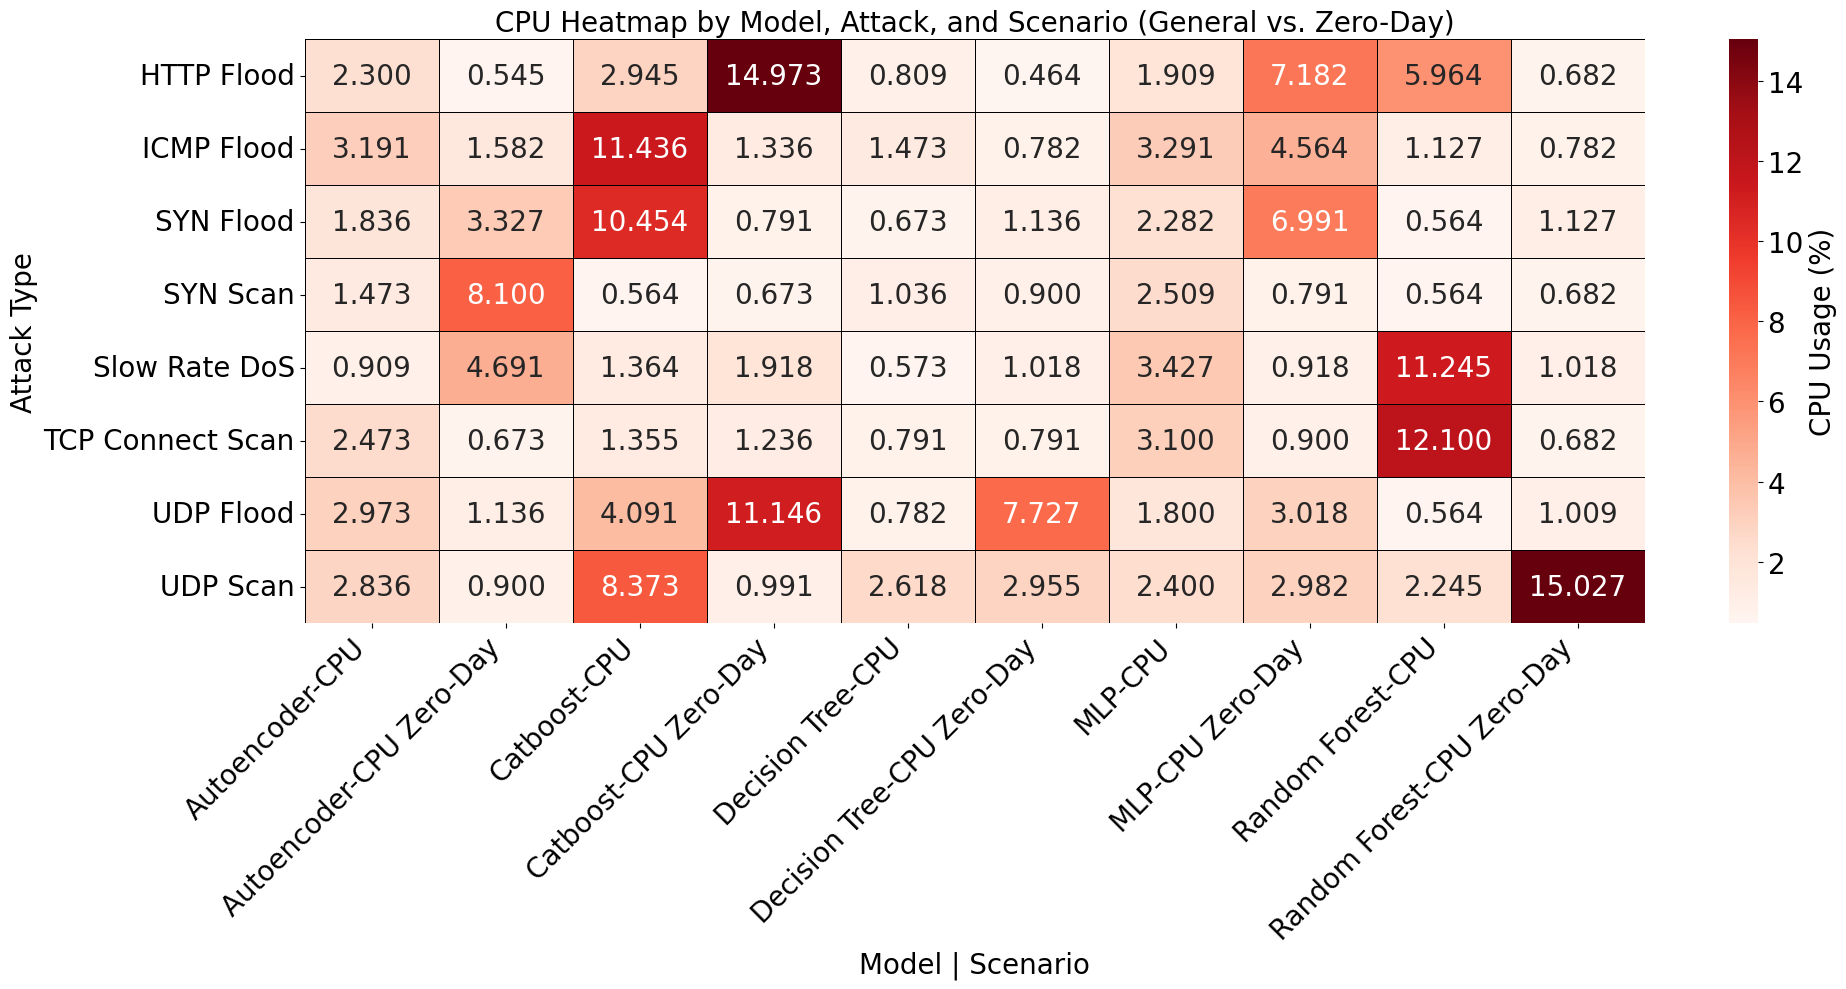

In [11]:
data_cpu_heatmap = df[['Model', 'Ataque Zero-Day', 'CPU', 'ZD - CPU']]
data_cpu_heatmap = data_cpu_heatmap.rename(columns={'ZD - CPU': 'CPU Zero-Day', 'Ataque Zero-Day': 'Attack Zero-Day'})

df_melted_cpu = data_cpu_heatmap.melt(
    id_vars=['Model', 'Attack Zero-Day'],
    value_vars=['CPU', 'CPU Zero-Day'],
    var_name='Scenario',
    value_name='Uso de CPU'
)

df_pivot_cpu = df_melted_cpu.pivot_table(
    index='Attack Zero-Day',
    columns=['Model', 'Scenario'],
    values='Uso de CPU'
)

plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    df_pivot_cpu,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'CPU Usage (%)'},
    annot_kws={"fontsize": 20}
)

plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

cbar = ax.collections[0].colorbar
cbar.set_label('CPU Usage (%)', fontsize=20)

cbar.ax.tick_params(labelsize=20)


plt.title('CPU Heatmap by Model, Attack, and Scenario (General vs. Zero-Day)', fontsize=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Memory

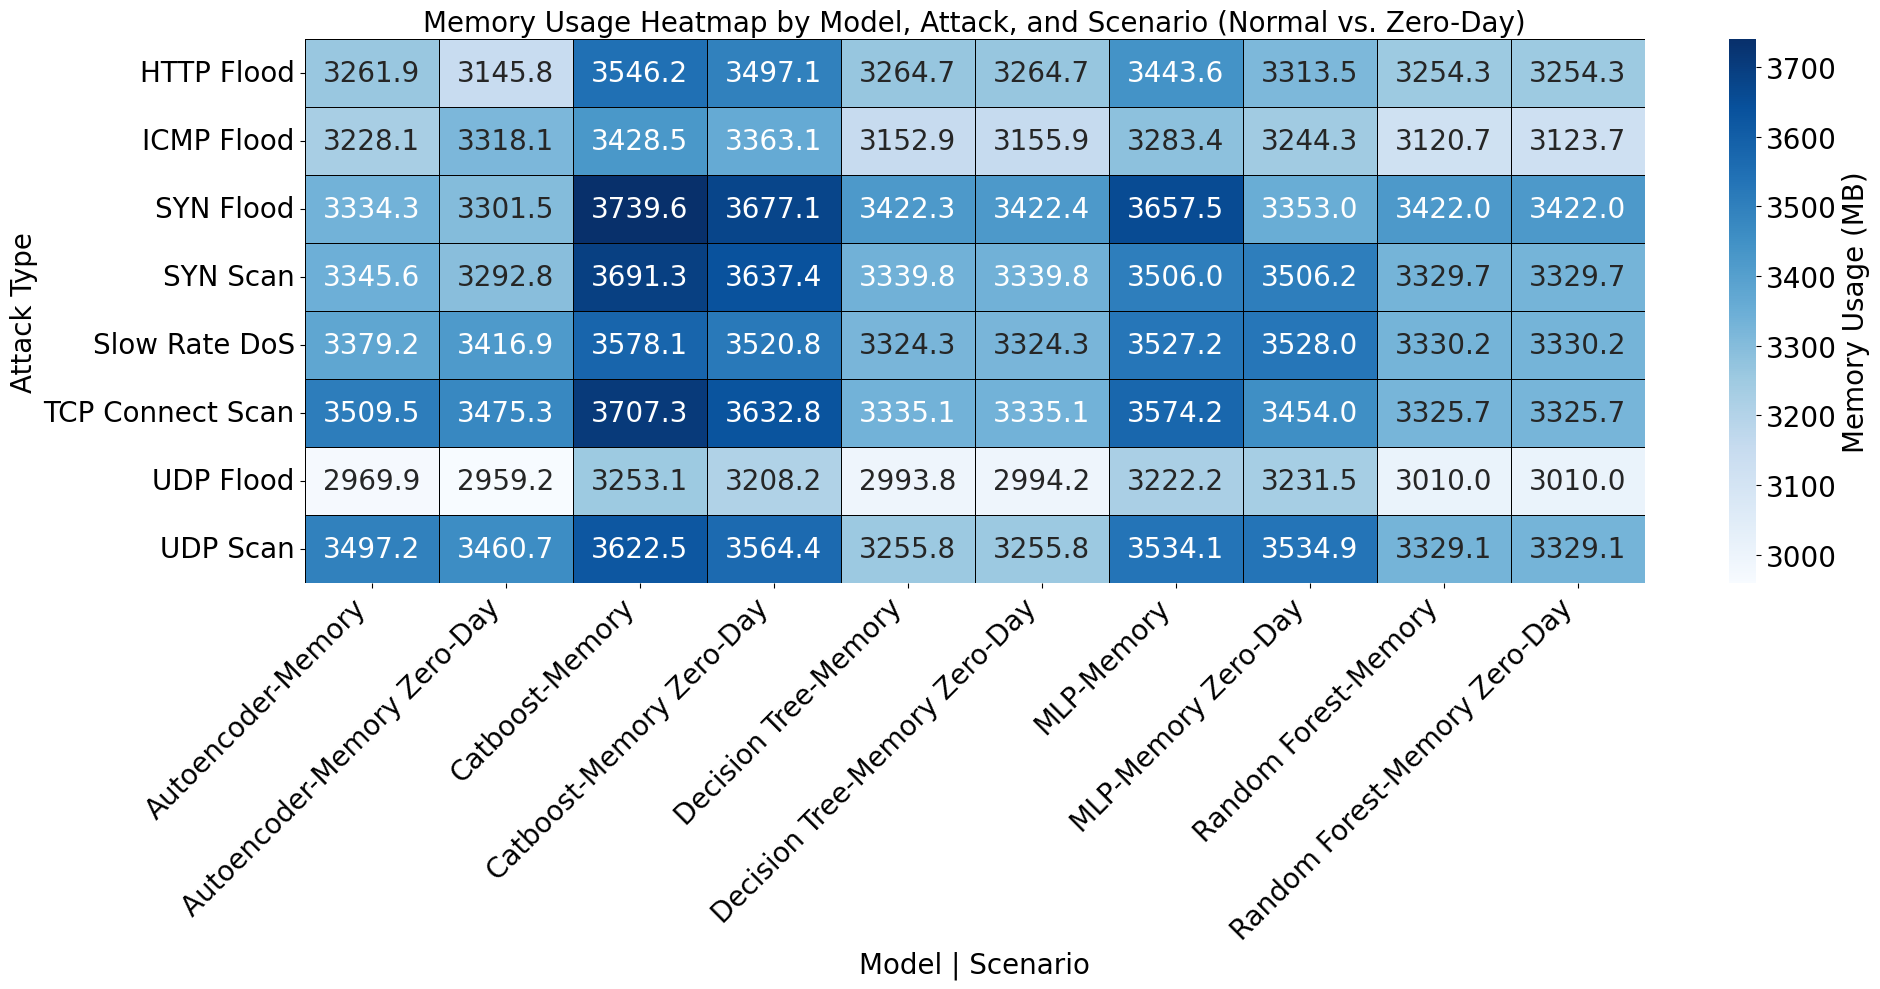

In [12]:
data_memory_heatmap = df[['Model', 'Ataque Zero-Day', 'Memory', 'ZD - Memory']]

data_memory_heatmap = data_memory_heatmap.rename(columns={
    'Modelo': 'Model',
    'Ataque Zero-Day': 'Attack Zero-Day',
    'ZD - Memory': 'Memory Zero-Day'
})

df_melted_memory = data_memory_heatmap.melt(
    id_vars=['Model', 'Attack Zero-Day'],
    value_vars=['Memory', 'Memory Zero-Day'],
    var_name='Scenario',
    value_name='Memory Usage (MB)'
)

df_pivot_memory = df_melted_memory.pivot_table(
    index='Attack Zero-Day',
    columns=['Model', 'Scenario'],
    values='Memory Usage (MB)'
)

plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    df_pivot_memory,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Memory Usage (MB)'},
    annot_kws={"fontsize": 20}
)

plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

cbar = ax.collections[0].colorbar
cbar.set_label('Memory Usage (MB)', fontsize=20)

cbar.ax.tick_params(labelsize=20)

plt.title('Memory Usage Heatmap by Model, Attack, and Scenario (Normal vs. Zero-Day)', fontsize=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Energy

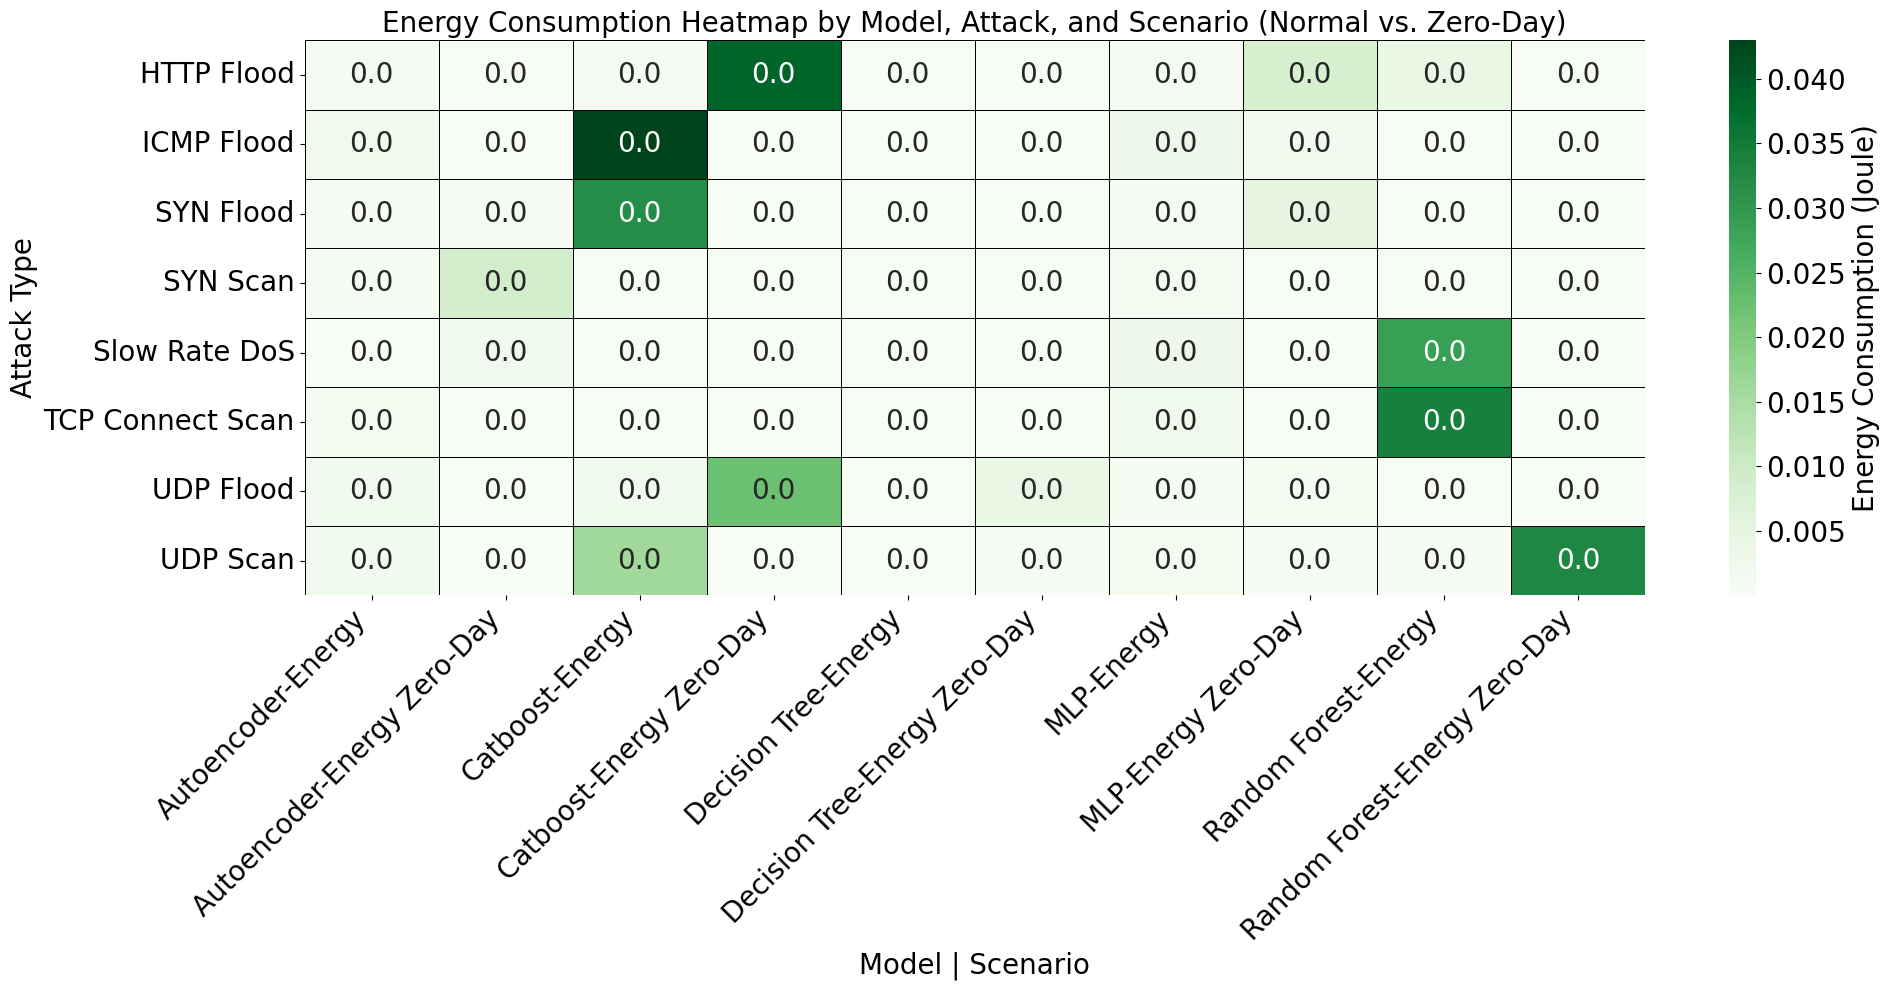

In [13]:
data_energy_heatmap = df[['Model', 'Ataque Zero-Day', 'Energy', 'ZD - Energy']]

data_energy_heatmap = data_energy_heatmap.rename(columns={
    'Modelo': 'Model',
    'Ataque Zero-Day': 'Attack Zero-Day',
    'ZD - Energy': 'Energy Zero-Day'
})

df_melted_energy = data_energy_heatmap.melt(
    id_vars=['Model', 'Attack Zero-Day'],
    value_vars=['Energy', 'Energy Zero-Day'],
    var_name='Scenario',
    value_name='Energy Consumption'
)

df_pivot_energy = df_melted_energy.pivot_table(
    index='Attack Zero-Day',
    columns=['Model', 'Scenario'],
    values='Energy Consumption'
)

plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    df_pivot_energy,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Energy Consumption (Joule)'},
    annot_kws={"fontsize": 20}
)

plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

cbar = ax.collections[0].colorbar
cbar.set_label('Energy Consumption (Joule)', fontsize=20)

cbar.ax.tick_params(labelsize=20)

plt.title('Energy Consumption Heatmap by Model, Attack, and Scenario (Normal vs. Zero-Day)', fontsize=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Time

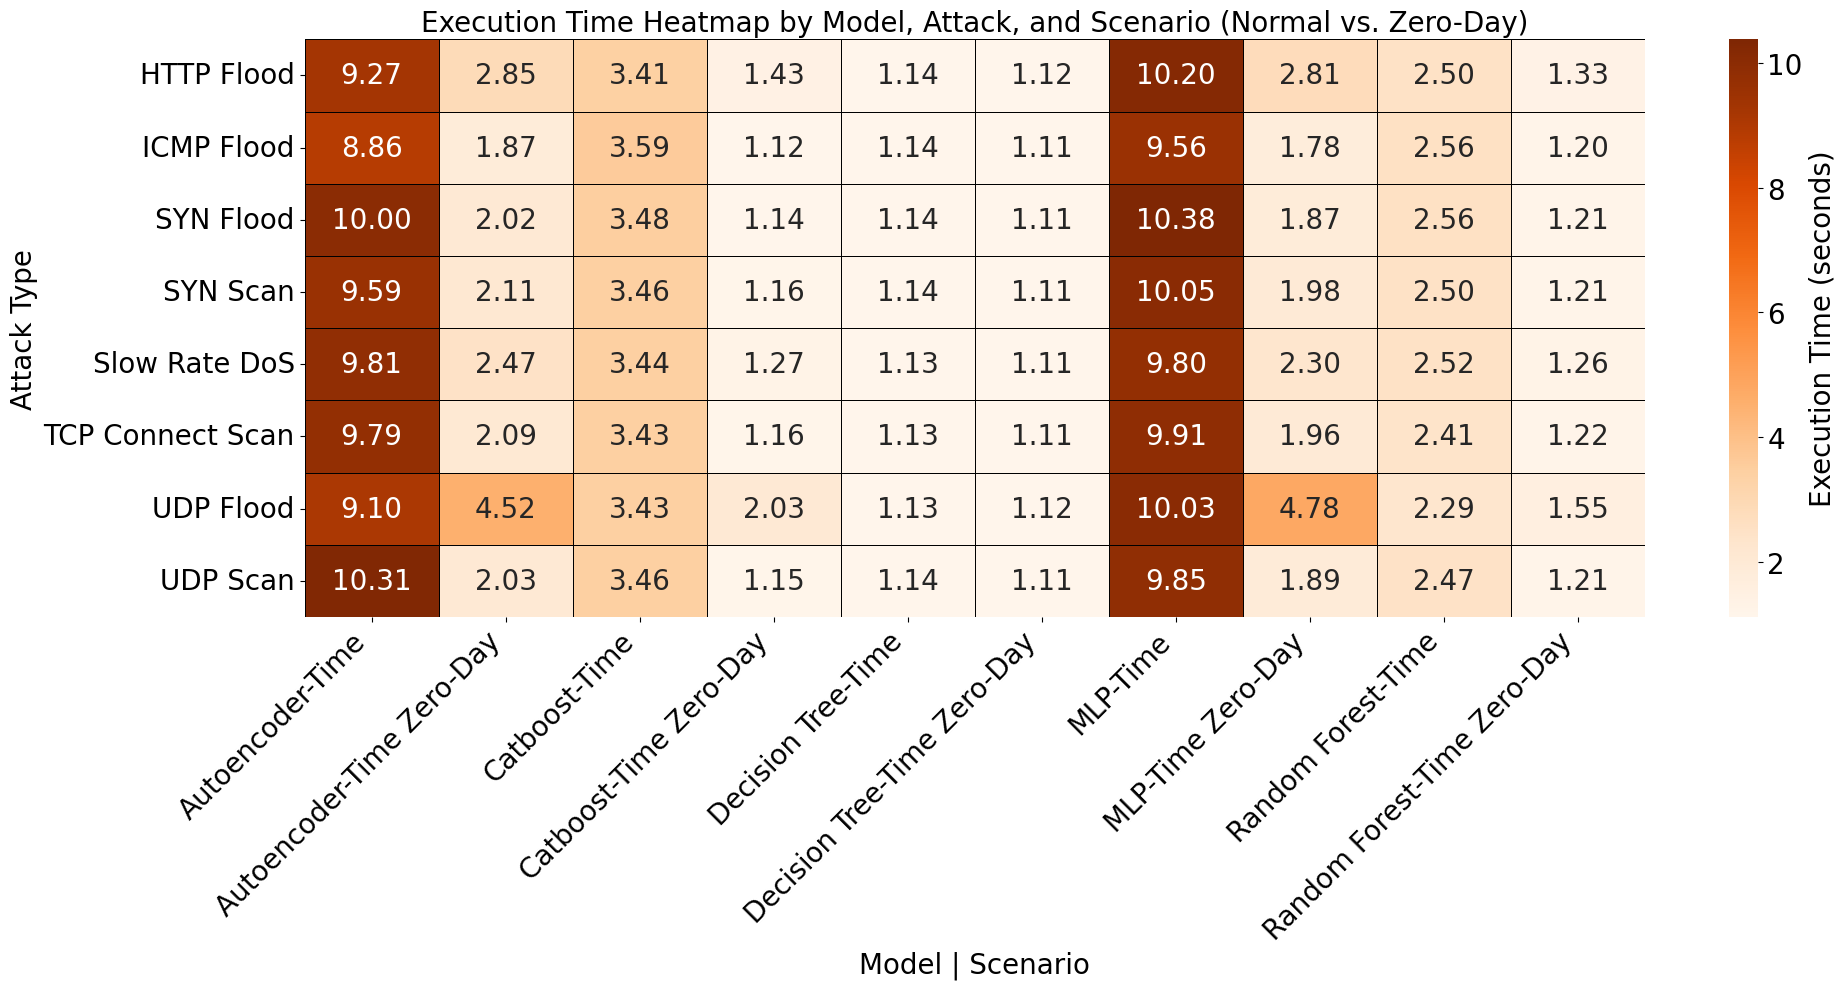

In [14]:
data_time_heatmap = df[['Model', 'Ataque Zero-Day', 'Time', 'ZD - Time']]

data_time_heatmap = data_time_heatmap.rename(columns={
    'Modelo': 'Model',
    'Ataque Zero-Day': 'Attack Zero-Day',
    'ZD - Time': 'Time Zero-Day'
})

df_melted_time = data_time_heatmap.melt(
    id_vars=['Model', 'Attack Zero-Day'],
    value_vars=['Time', 'Time Zero-Day'],
    var_name='Scenario',
    value_name='Execution Time (s)'
)

df_pivot_time = df_melted_time.pivot_table(
    index='Attack Zero-Day',
    columns=['Model', 'Scenario'],
    values='Execution Time (s)'
)

plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    df_pivot_time,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Execution Time (seconds)'},
    annot_kws={"fontsize": 20}
)

plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

cbar = ax.collections[0].colorbar
cbar.set_label('Execution Time (seconds)', fontsize=20)

cbar.ax.tick_params(labelsize=20)
plt.title('Execution Time Heatmap by Model, Attack, and Scenario (Normal vs. Zero-Day)', fontsize=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Barplot

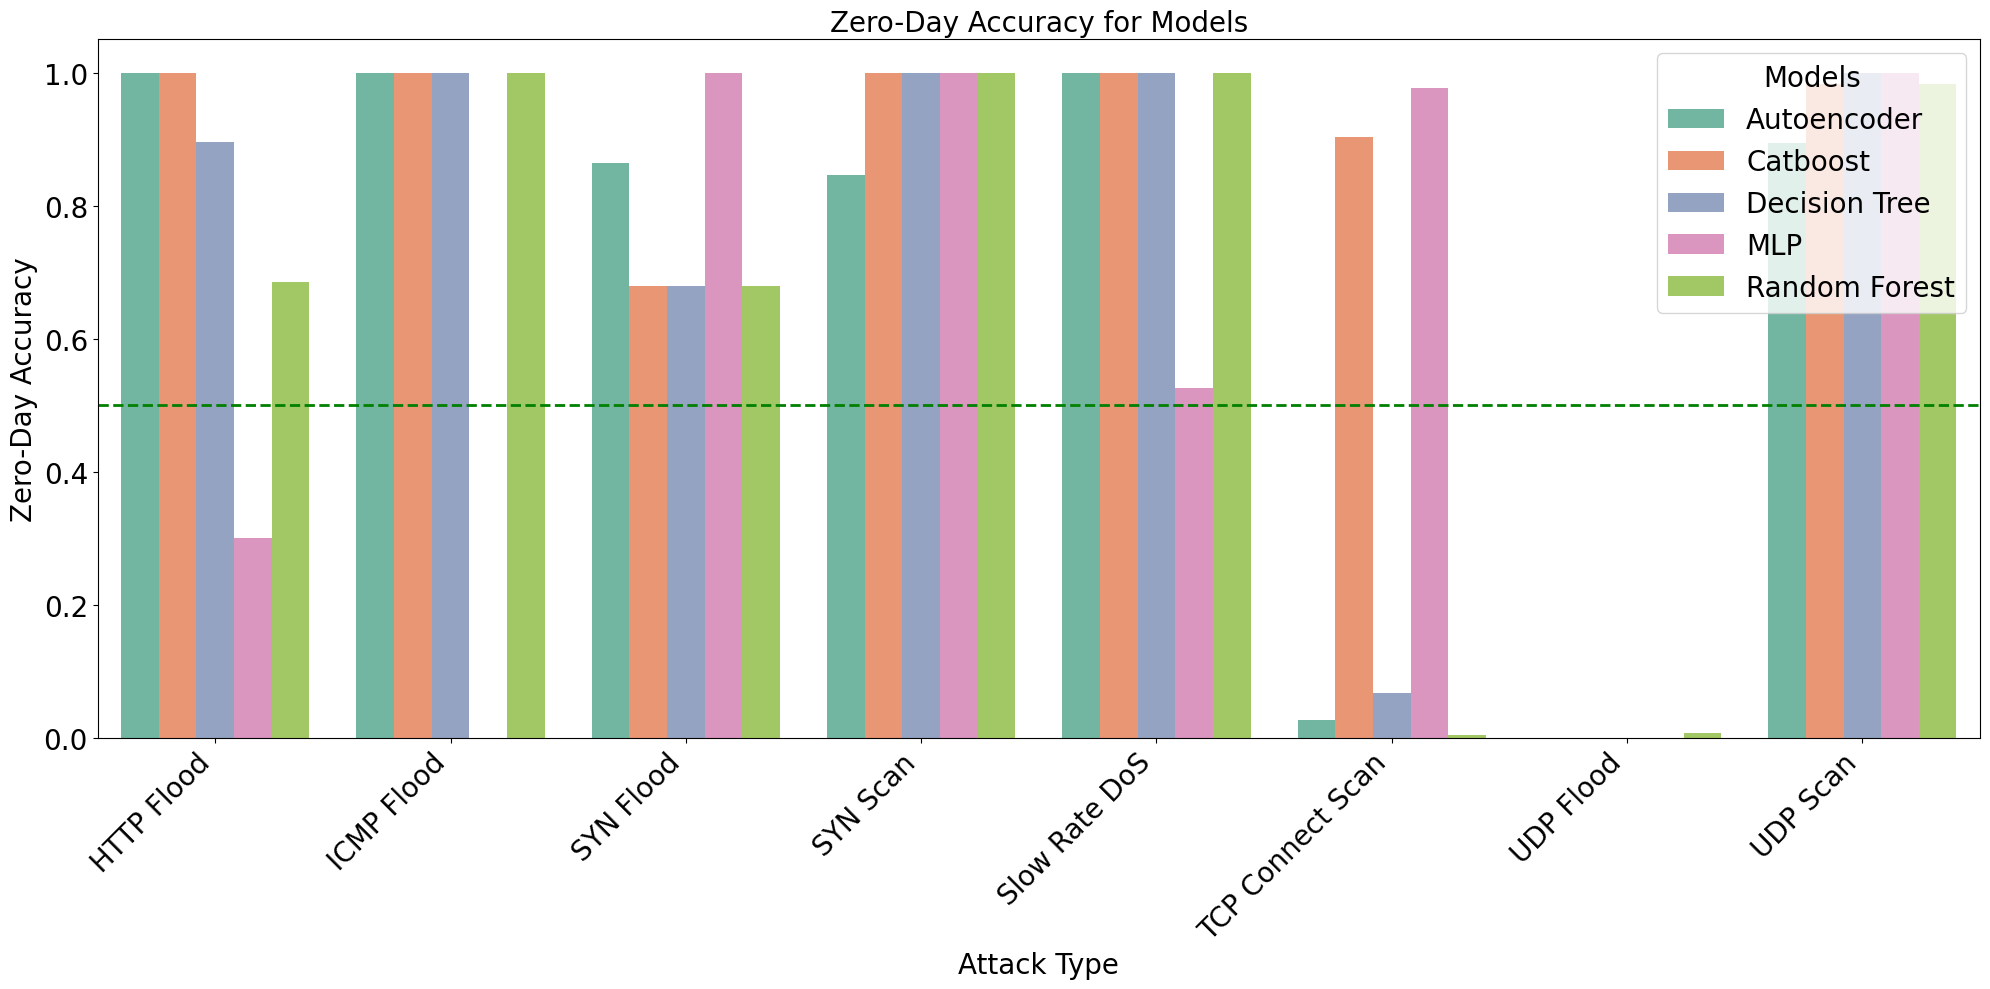

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_accuracy_zd = df[['Model', 'Ataque Zero-Day', 'ZD - Accuracy']]

df_plot = df_accuracy_zd.groupby(['Ataque Zero-Day', 'Model'])['ZD - Accuracy'].mean().reset_index()

plt.figure(figsize=(20, 10))

sns.barplot(
    x='Ataque Zero-Day',
    y='ZD - Accuracy',
    hue='Model',
    data=df_plot,
    palette='Set2'
)

plt.title('Zero-Day Accuracy for Models', fontsize=20)
plt.ylabel('Zero-Day Accuracy', fontsize=20)
plt.xlabel('Attack Type', fontsize=20)

plt.axhline(y=0.5, color='green', linestyle='--', linewidth=2)

plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

plt.legend(
    title='Models',
    loc='upper right',
    fontsize=20,
    title_fontsize=20
)

plt.tight_layout()
plt.show()

# Training vs Test

In [16]:
df_train_string = '''
Model,attack,total_time_train,avg_cpu_train,avg_mem_train,energy_train
Decision Tree,ICMPFlood,9.08841,49.95,3130.22,9.06117
Decision Tree,UDPFlood,6.97851,49.95,2988.01,6.9576
Decision Tree,SYNFlood,8.94428,50.0,3422.33,8.94428
Decision Tree,SYNScan,9.10166,49.95,3339.81,9.07438
Decision Tree,HTTPFlood,7.16761,49.75,3264.66,7.06063
Decision Tree,UDPScan,11.8248,50.0,3255.81,11.8248
Decision Tree,TCPConnectScan,8.8405,50.0,3335.09,8.8405
Decision Tree,SlowrateDoS,8.66296,50.0,3324.33,8.66296
Random Forest,ICMPFlood,140.608,49.95,3102.72,140.187
Random Forest,UDPFlood,94.1844,49.9,2995.44,93.6204
Random Forest,SYNFlood,156.284,49.9,3421.97,155.348
Random Forest,SYNScan,134.99,49.7,3329.73,132.575
Random Forest,HTTPFlood,100.147,49.9,3254.34,99.5477
Random Forest,UDPScan,136.851,49.95,3329.04,136.441
Random Forest,TCPConnectScan,129.417,49.85,3325.66,128.256
Random Forest,SlowrateDoS,115.615,49.95,3330.21,115.269
Catboost,ICMPFlood,103.356,98.9,3805.42,799.864
Catboost,UDPFlood,60.9728,99.3,3653.43,477.61
Catboost,SYNFlood,103.621,98.9,3834.76,801.915
Catboost,SYNScan,104.656,98.8,3888.04,807.468
Catboost,HTTPFlood,80.7903,98.9,3677.76,625.227
Catboost,UDPScan,103.691,98.85,3828.5,801.234
Catboost,TCPConnectScan,92.9354,99.1,3890.44,723.589
Catboost,SlowrateDoS,94.8382,98.9,3863.98,733.943
MLP,ICMPFlood,219.89,1.245,3477.4,0.00339471
MLP,UDPFlood,150.84,1.56,3214.05,0.00458121
MLP,SYNFlood,109.886,0.5,3588.05,0.000109886
MLP,SYNScan,110.636,0.25,3633.24,1.38295e-05
MLP,HTTPFlood,93.9596,2.8,3506.46,0.0165008
MLP,UDPScan,105.671,2.95,3730.24,0.0217027
MLP,TCPConnectScan,107.1,0.63,3709.81,0.000214241
MLP,SlowrateDoS,101.682,1.87,3707.1,0.00531933
Autoencoder,ICMPFlood,267.063,2.89167,2847.96,0.0516593
Autoencoder,UDPFlood,213.499,1.8225,2872.94,0.0103392
Autoencoder,SYNFlood,84.2763,0.51,3369.26,8.94347e-05
Autoencoder,SYNScan,88.0945,0.38,3516.84,3.86714e-05
Autoencoder,HTTPFlood,72.9844,4.6,3396.27,0.0568321
Autoencoder,UDPScan,87.0829,3.53,3636.1,0.0306441
Autoencoder,TCPConnectScan,87.4253,6.69,3687.86,0.209414
Autoencoder,SlowrateDoS,81.7727,3.76,3629.91,0.0347746
'''

In [17]:
# --- 1. Carregar os Dados ---
df_train = pd.read_csv(io.StringIO(df_train_string))
df_test = pd.read_csv(io.StringIO(df_test))

##CPU

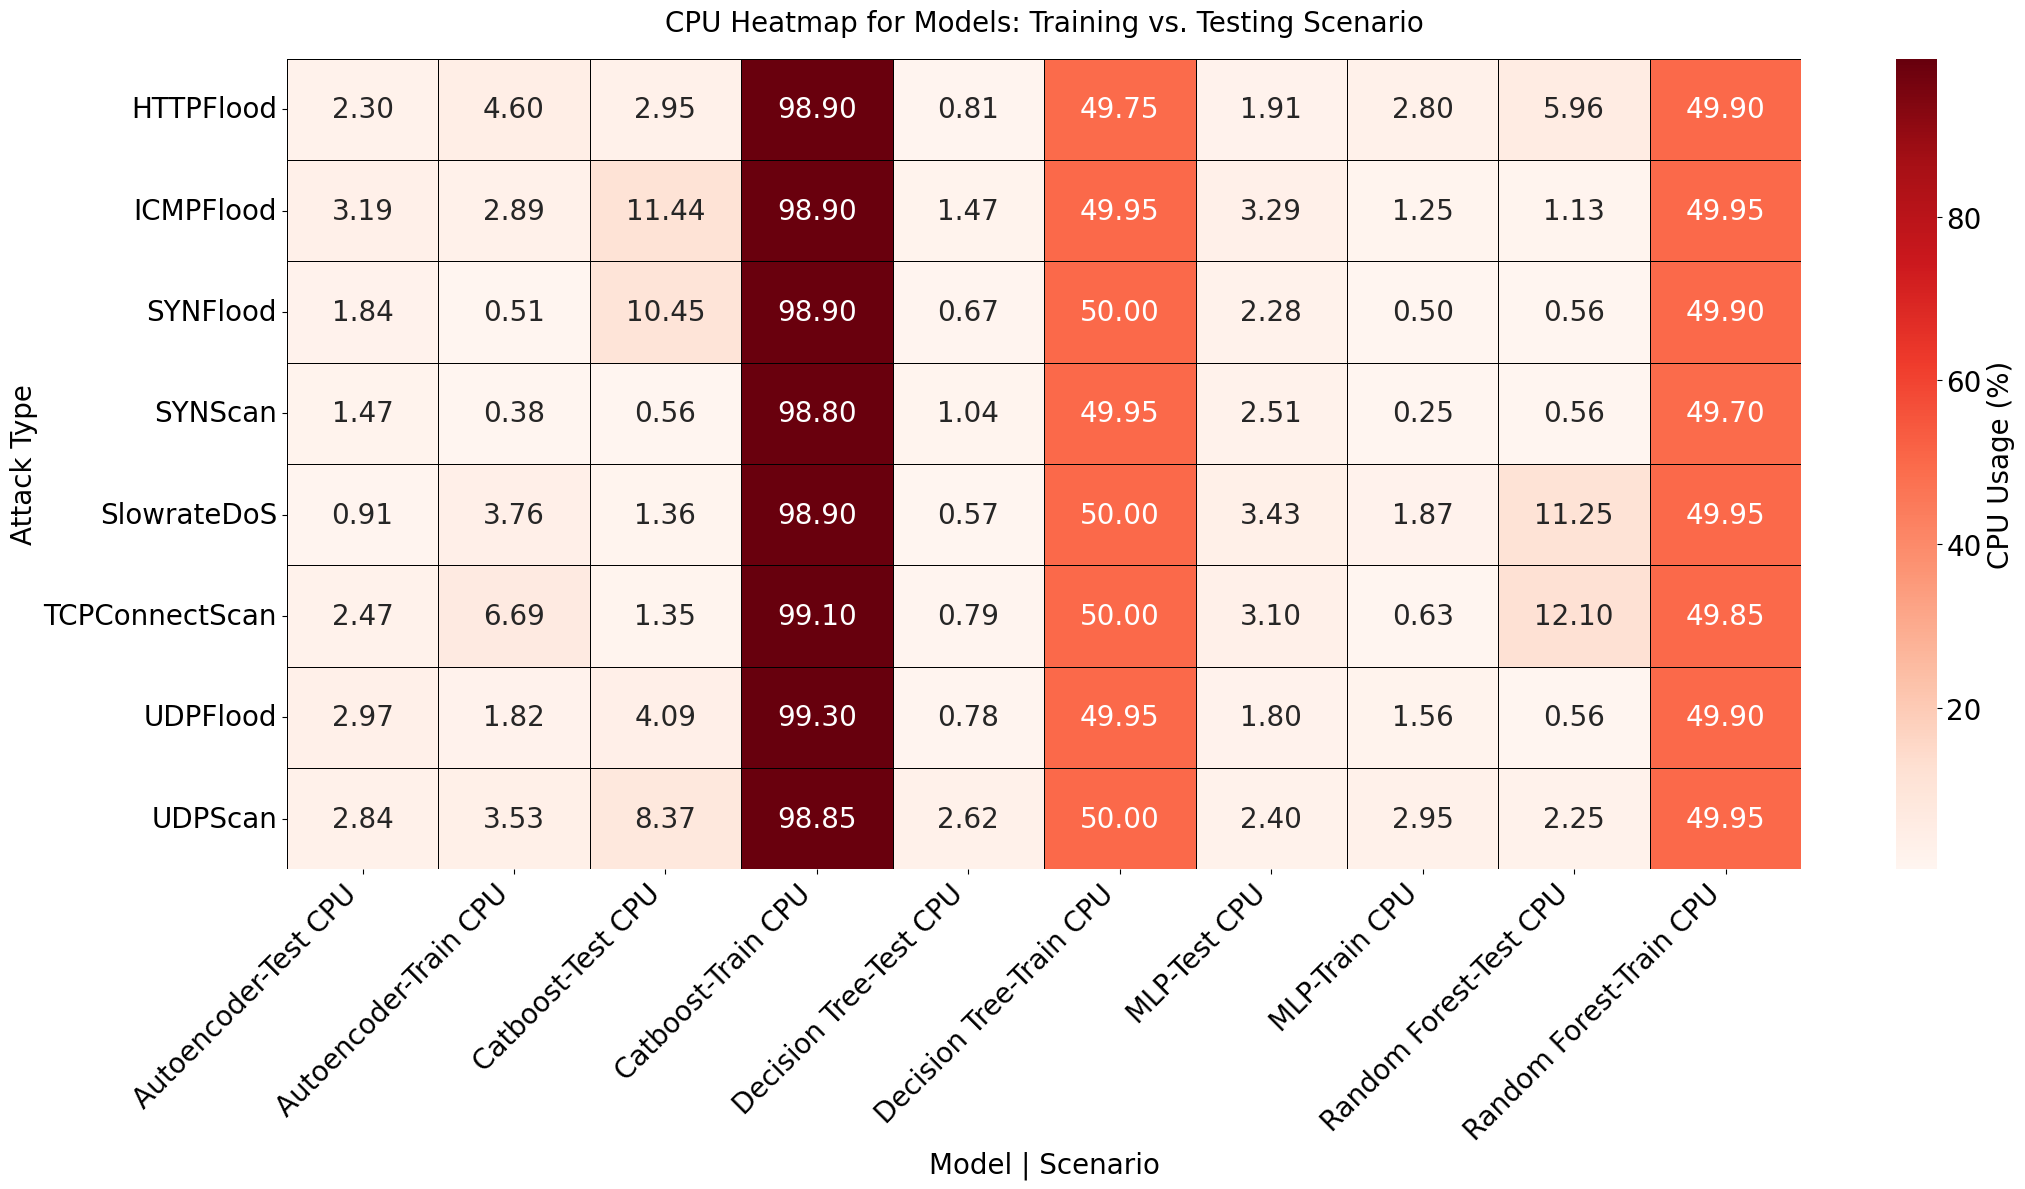

In [18]:

# --- 2. Preparação dos Dados ---
# Selecionar e renomear colunas do DataFrame de Treinamento
df_cpu_train = df_train[['Model', 'attack', 'avg_cpu_train']].rename(
    columns={'attack': 'Attack', 'avg_cpu_train': 'Train CPU'}
)

# Selecionar e renomear colunas do DataFrame de Teste
df_cpu_test = df_test[['Model', 'Ataque Zero-Day', 'CPU']].rename(
    columns={'Ataque Zero-Day': 'Attack', 'CPU': 'Test CPU'}
)

# Mesclar os DataFrames
df_cpu_combined = pd.merge(df_cpu_train, df_cpu_test, on=['Model', 'Attack'])

# Derreter (Melt) o DataFrame para ter o formato longo
df_melted_cpu = df_cpu_combined.melt(
    id_vars=['Model', 'Attack'],
    value_vars=['Train CPU', 'Test CPU'],
    var_name='Scenario',
    value_name='CPU Usage (%)'
)

# Pivotar para o formato do Heatmap (Attack vs. Model | Scenario)
df_pivot_cpu = df_melted_cpu.pivot_table(
    index='Attack',
    columns=['Model', 'Scenario'],
    values='CPU Usage (%)',
    aggfunc='mean'
)

# --- 3. Geração do Heatmap ---
plt.figure(figsize=(22, 12)) # Aumentei o tamanho para acomodar 15 colunas

ax = sns.heatmap(
    df_pivot_cpu,
    annot=True,
    fmt=".2f", # Formato de duas casas decimais
    cmap="Reds", # Paleta de cores quente (amarelo-laranja-vermelho) para CPU
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'CPU Usage (%)'},
    annot_kws={"fontsize": 20}
)

# Estilização
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(rotation=0, fontsize=20)

# Ajuste do Label da Barra de Cor
cbar = ax.collections[0].colorbar
cbar.set_label('CPU Usage (%)', fontsize=20)
cbar.ax.tick_params(labelsize=20)

# Títulos e Labels
plt.title('CPU Heatmap for Models: Training vs. Testing Scenario', fontsize=20, pad=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)


plt.tight_layout()
plt.show()

## Memory

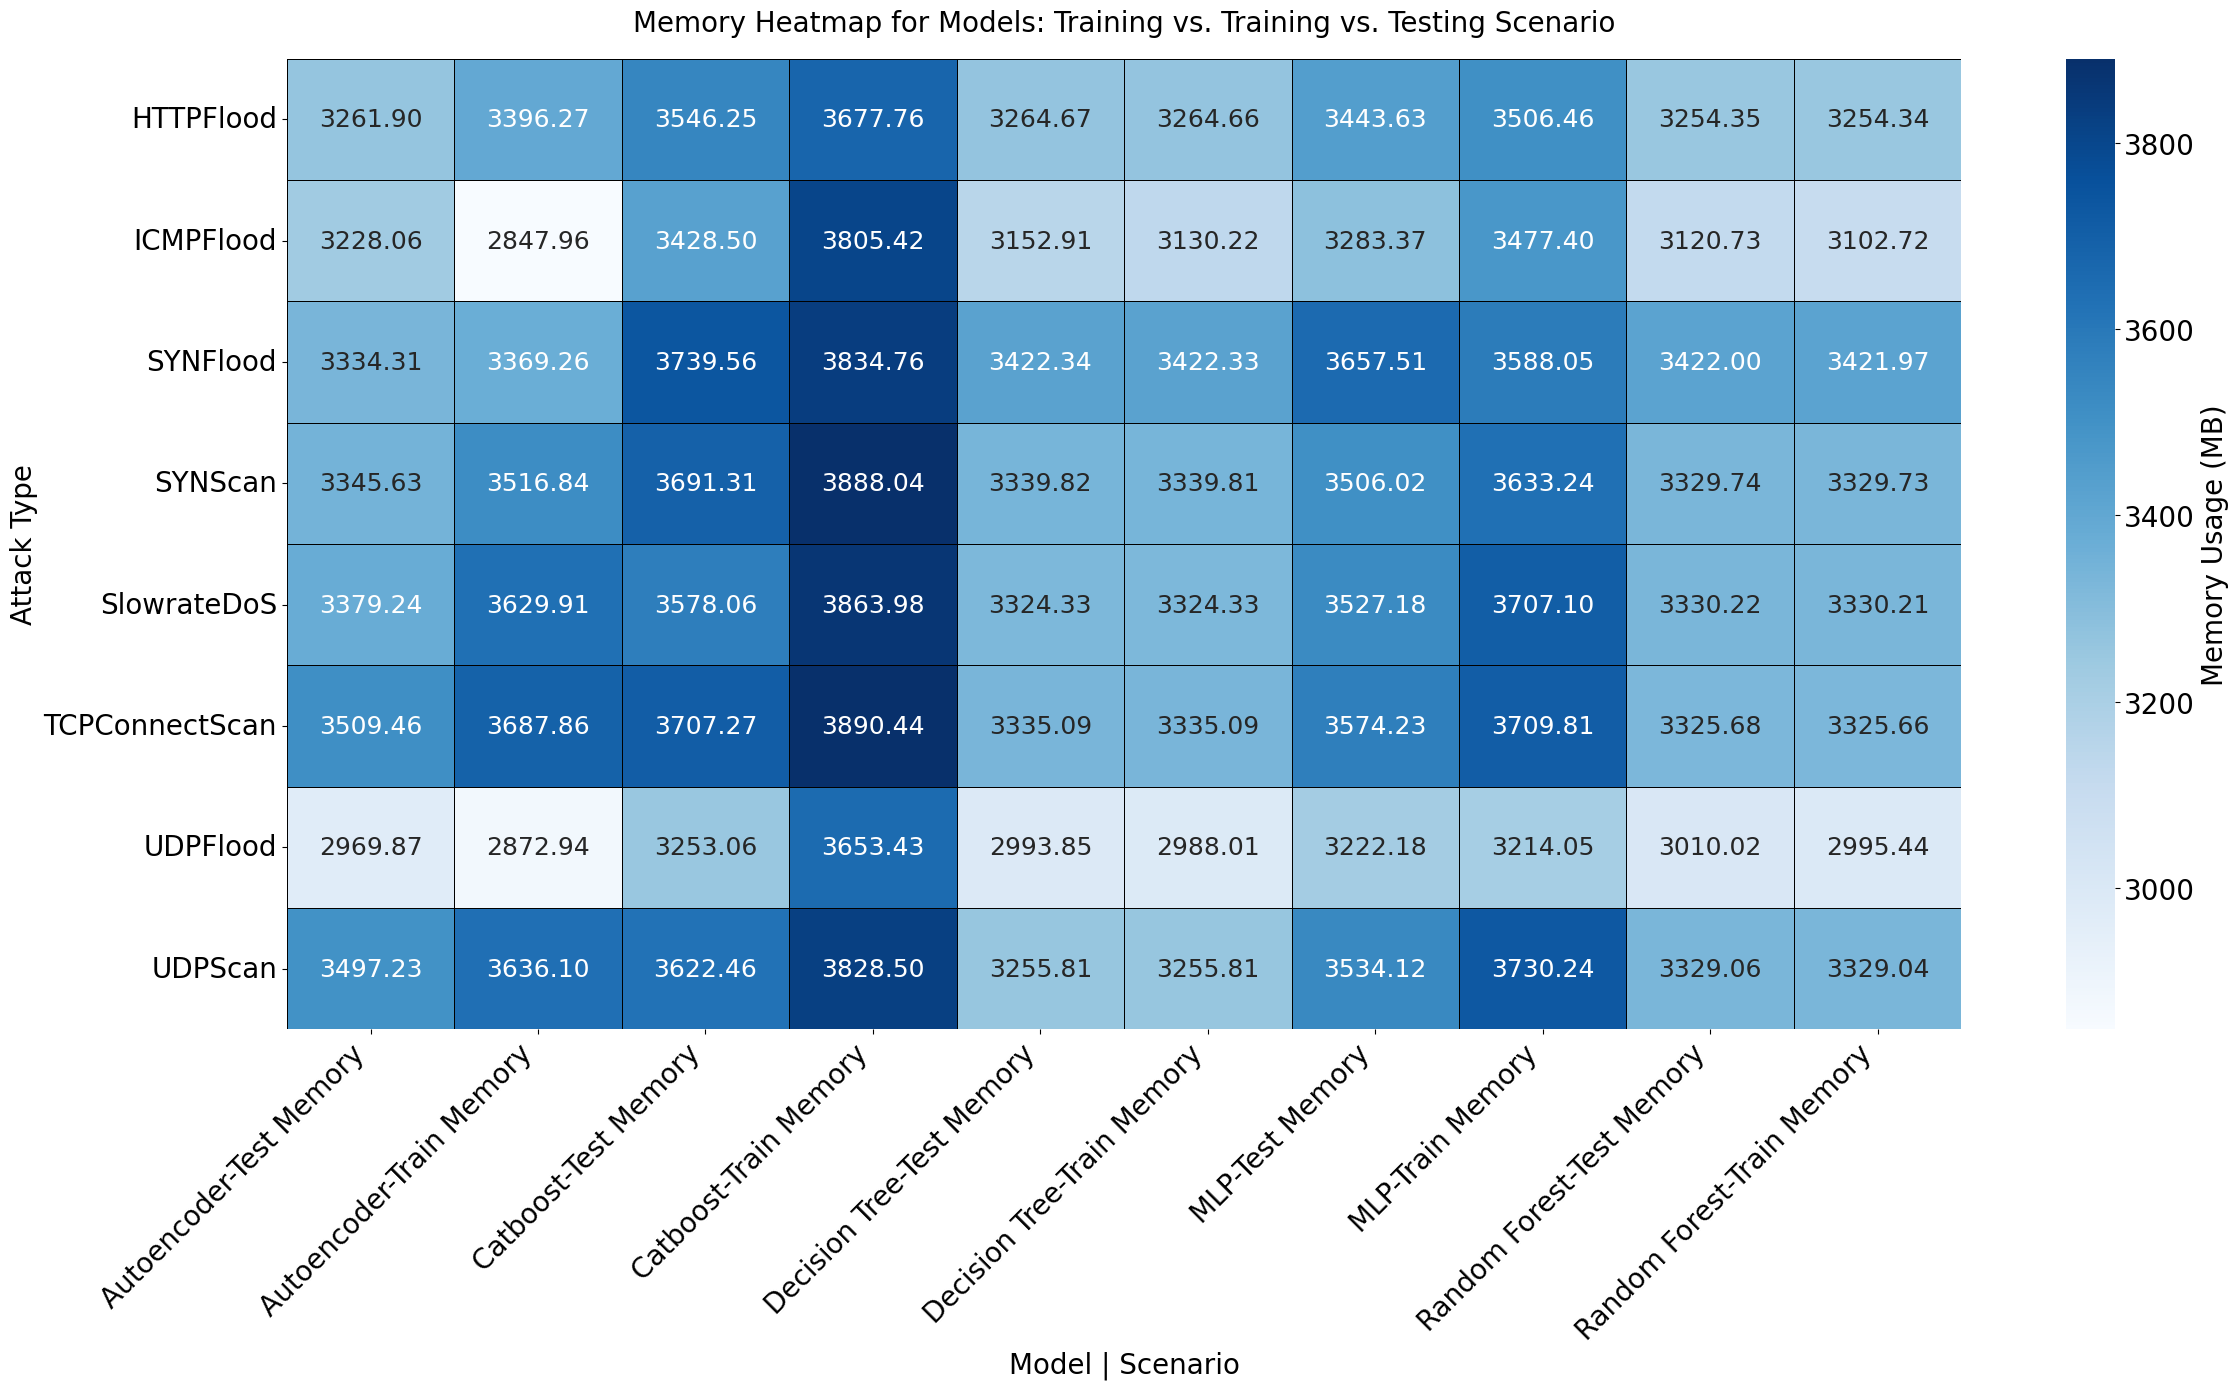

In [19]:
df_mem_train = df_train[['Model', 'attack', 'avg_mem_train']].rename(
    columns={'attack': 'Attack', 'avg_mem_train': 'Train Memory'}
)

# Selecionar e renomear colunas do DataFrame de Teste (Memória)
df_mem_test = df_test[['Model', 'Ataque Zero-Day', 'Memory']].rename(
    columns={'Ataque Zero-Day': 'Attack', 'Memory': 'Test Memory'}
)

# Mesclar os DataFrames de Memória
df_mem_combined = pd.merge(df_mem_train, df_mem_test, on=['Model', 'Attack'])

# Derreter (Melt) o DataFrame para ter o formato longo
df_melted_mem = df_mem_combined.melt(
    id_vars=['Model', 'Attack'],
    value_vars=['Train Memory', 'Test Memory'],
    var_name='Scenario',
    value_name='Memory Usage (MB)' # Unidade de Memória (MegaBytes)
)

# Pivotar para o formato do Heatmap (Attack vs. Model | Scenario)
df_pivot_mem = df_melted_mem.pivot_table(
    index='Attack',
    columns=['Model', 'Scenario'],
    values='Memory Usage (MB)',
    aggfunc='mean'
)

# --- 3. Geração do Heatmap de Memória ---
# Adaptando as configurações de plotagem para Memória
plt.figure(figsize=(24, 14))

# Paleta de cores para Memória (usei GnBu, Verde-Azul, para contraste com CPU)
ax = sns.heatmap(
    df_pivot_mem,
    annot=True,
    fmt=".2f",
    cmap="Blues", # Paleta de cores para Memória
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Memory Usage (MB)'},
    annot_kws={"fontsize": 18}
)

# Estilização
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(rotation=0, fontsize=20)

# Ajuste do Label da Barra de Cor
cbar = ax.collections[0].colorbar
cbar.set_label('Memory Usage (MB)', fontsize=20)
cbar.ax.tick_params(labelsize=20)

# Adaptação do Título para Memória (conforme solicitado)
plt.title('Memory Heatmap for Models: Training vs. Training vs. Testing Scenario', fontsize=20, pad=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)

plt.tight_layout()
plt.show()

## Energy

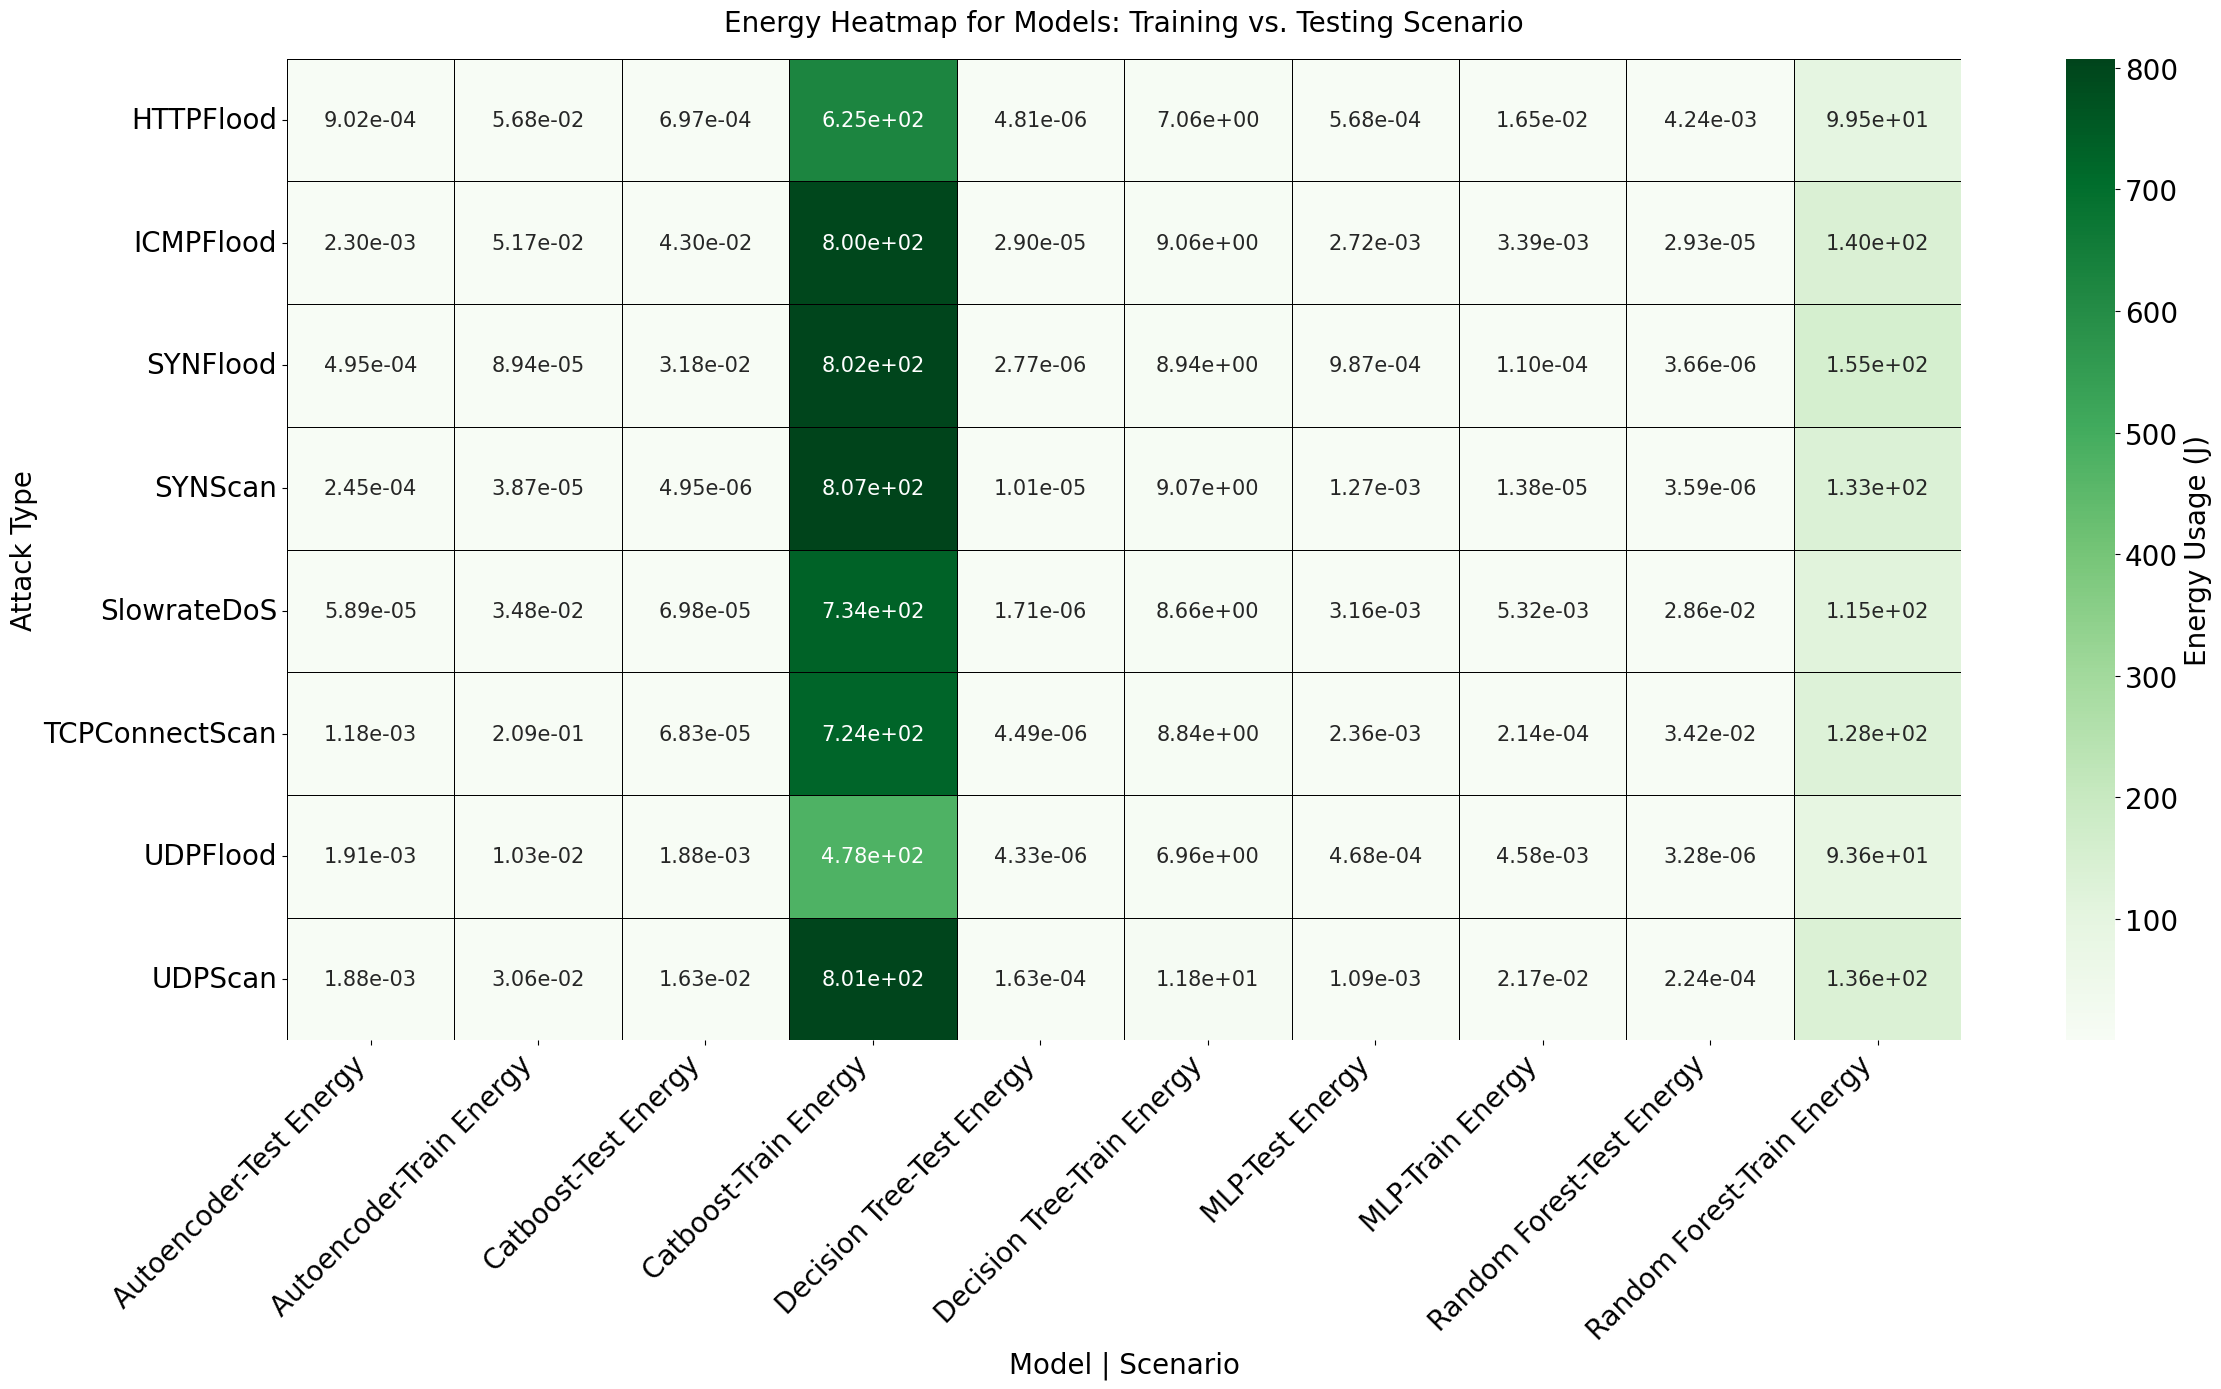

In [27]:
# Selecionar e renomear colunas do DataFrame de Treinamento
df_energy_train = df_train[['Model', 'attack', 'energy_train']].rename(
    columns={'attack': 'Attack', 'energy_train': 'Train Energy'}
)

# Selecionar e renomear colunas do DataFrame de Teste
df_energy_test = df_test[['Model', 'Ataque Zero-Day', 'Energy']].rename(
    columns={'Ataque Zero-Day': 'Attack', 'Energy': 'Test Energy'}
)

# Mesclar os DataFrames de Energia
df_energy_combined = pd.merge(df_energy_train, df_energy_test, on=['Model', 'Attack'])

# Derreter (Melt) o DataFrame para ter o formato longo
df_melted_energy = df_energy_combined.melt(
    id_vars=['Model', 'Attack'],
    value_vars=['Train Energy', 'Test Energy'],
    var_name='Scenario',
    value_name='Energy Usage (J)' # Unidade de Energia (Joules), pode precisar de ajuste na escala
)

# Pivotar para o formato do Heatmap (Attack vs. Model | Scenario)
df_pivot_energy = df_melted_energy.pivot_table(
    index='Attack',
    columns=['Model', 'Scenario'],
    values='Energy Usage (J)',
    aggfunc='mean'
)

# --- 3. Geração do Heatmap de Energia ---

# Se os valores de energia forem muito grandes é bom dividi-los por 1 milhão (MegaJoules) ou 1000 (KiloJoules)

#df_pivot_energy = df_pivot_energy / 1000000

plt.figure(figsize=(24, 14))

# Paleta de cores para Energia (usei "YlGnBu" - Amarelo-Verde-Azul)
ax = sns.heatmap(
    df_pivot_energy,
    annot=True,
    fmt=".2e",
    cmap="Greens", # Paleta de cores para Energia
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Energy Usage (J)'},
    annot_kws={"fontsize": 15}
)

# Estilização
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(rotation=0, fontsize=20)

# Ajuste do Label da Barra de Cor
cbar = ax.collections[0].colorbar
cbar.set_label('Energy Usage (J)', fontsize=20)
cbar.ax.tick_params(labelsize=20)

# Adaptação do Título para Energia
plt.title('Energy Heatmap for Models: Training vs. Testing Scenario', fontsize=20, pad=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)

plt.tight_layout()
plt.show()

## Time

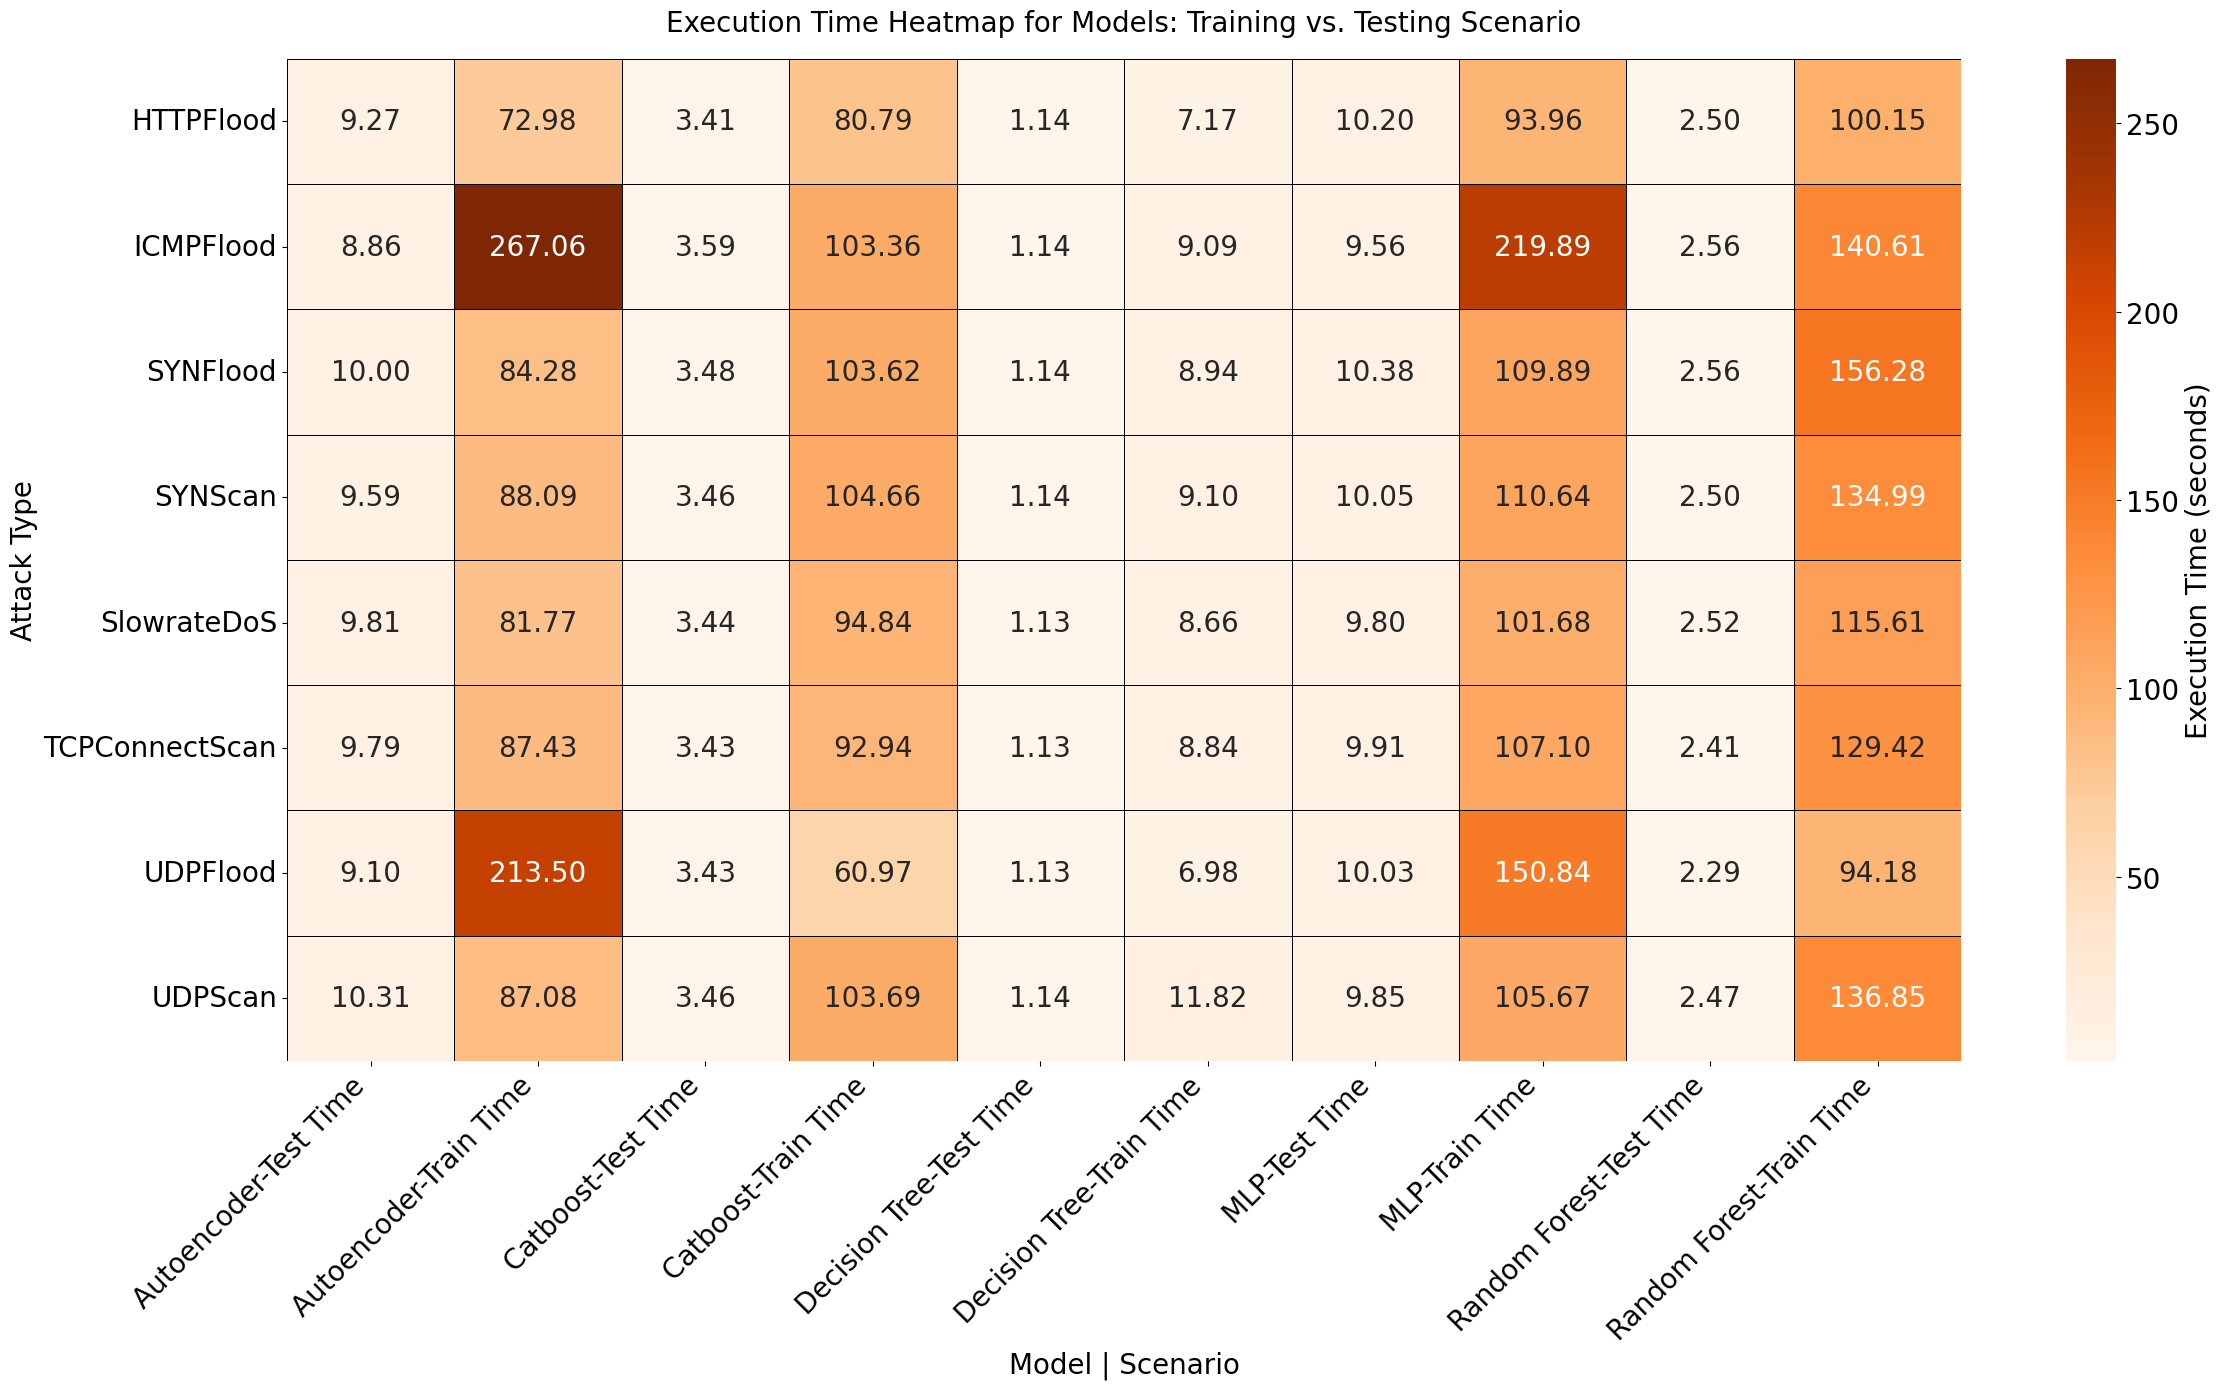

In [21]:
# Selecionar e renomear colunas do DataFrame de Treinamento
df_time_train = df_train[['Model', 'attack', 'total_time_train']].rename(
    columns={'attack': 'Attack', 'total_time_train': 'Train Time'}
)

# Selecionar e renomear colunas do DataFrame de Teste
df_time_test = df_test[['Model', 'Ataque Zero-Day', 'Time']].rename(
    columns={'Ataque Zero-Day': 'Attack', 'Time': 'Test Time'}
)

# Mesclar os DataFrames de Tempo
df_time_combined = pd.merge(df_time_train, df_time_test, on=['Model', 'Attack'])

# Derreter (Melt) o DataFrame para ter o formato longo
df_melted_time = df_time_combined.melt(
    id_vars=['Model', 'Attack'],
    value_vars=['Train Time', 'Test Time'],
    var_name='Scenario',
    value_name='Execution Time (s)' # Unidade de Tempo (Segundos)
)

# Pivotar para o formato do Heatmap (Attack vs. Model | Scenario)
df_pivot_time = df_melted_time.pivot_table(
    index='Attack',
    columns=['Model', 'Scenario'],
    values='Execution Time (s)',
    aggfunc='mean'
)

# --- 3. Geração do Heatmap de Tempo de Execução ---

plt.figure(figsize=(24, 14))

# Paleta de cores para Tempo (Sugestão: "Blues" ou "PuBuGn" - Cores frias para tempo)
ax = sns.heatmap(
    df_pivot_time,
    annot=True,
    fmt=".2f",
    cmap="Oranges", # Paleta de cores para Tempo
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Execution Time (seconds)'},
    annot_kws={"fontsize": 20} # Mantido em 14 para legibilidade dos números
)

# Estilização com fontsize=20
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(rotation=0, fontsize=20)

# Ajuste do Label da Barra de Cor
cbar = ax.collections[0].colorbar
cbar.set_label('Execution Time (seconds)', fontsize=20)
cbar.ax.tick_params(labelsize=20)

# Adaptação do Título para Tempo
plt.title('Execution Time Heatmap for Models: Training vs. Testing Scenario', fontsize=20, pad=20)
plt.xlabel('Model | Scenario', fontsize=20)
plt.ylabel('Attack Type', fontsize=20)

plt.tight_layout()
plt.show()

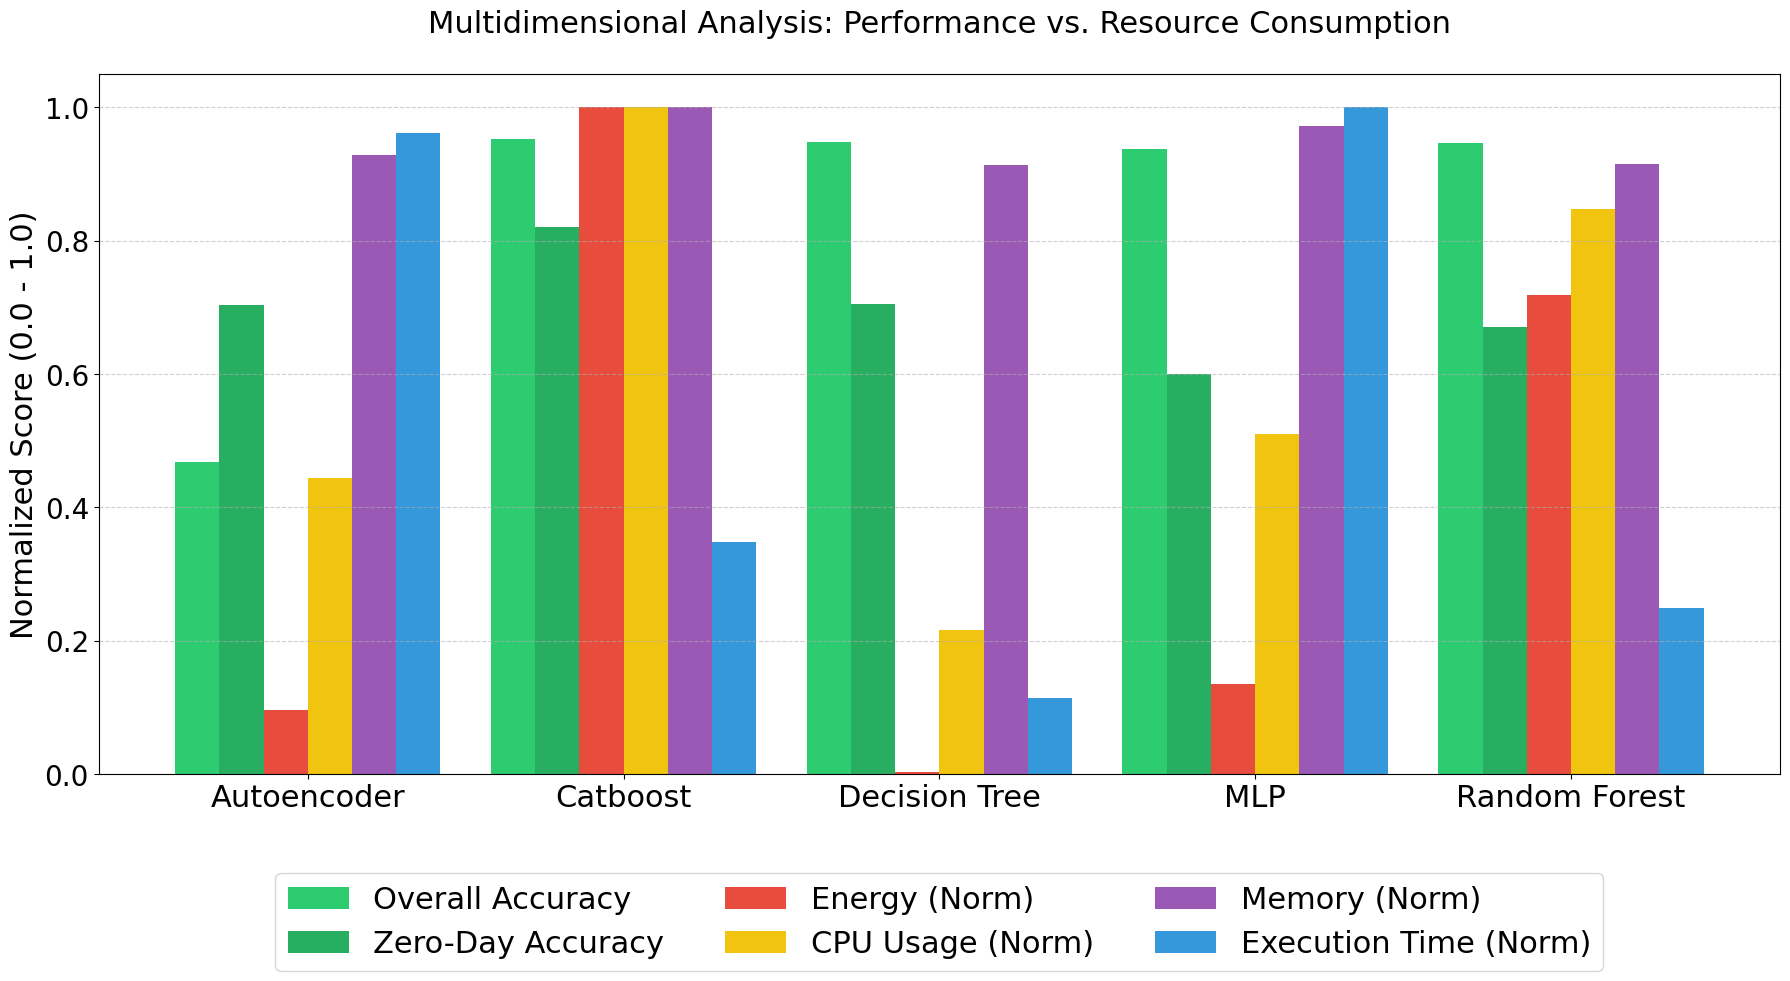

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Group means by model for Dataset 1
df_summary_1 = df.groupby('Model').agg({
    'Accuracy': 'mean',
    'ZD - Accuracy': 'mean',
    'Energy': 'mean',
    'CPU': 'mean',
    'Memory': 'mean',
    'Time': 'mean'
}).reset_index()

# 2. Normalization (Scale 0 to 1) to enable visual comparison
cols_to_norm = ['Energy', 'CPU', 'Memory', 'Time']
for col in cols_to_norm:
    df_summary_1[f'{col}_Norm'] = df_summary_1[col] / df_summary_1[col].max()

# 3. Chart Configuration
labels = df_summary_1['Model'].values
x = np.arange(len(labels))
width = 0.14

fig, ax = plt.subplots(figsize=(18, 10))

# Distinct colors for the slide
# Green (Success) | Red/Yellow/Purple/Blue (Costs)
colors = ['#2ecc71', '#27ae60', '#e74c3c', '#f1c40f', '#9b59b6', '#3498db']

# Plotting the 6 metrics
ax.bar(x - 2.5*width, df_summary_1['Accuracy'], width, label='Overall Accuracy', color=colors[0])
ax.bar(x - 1.5*width, df_summary_1['ZD - Accuracy'], width, label='Zero-Day Accuracy', color=colors[1])
ax.bar(x - 0.5*width, df_summary_1['Energy_Norm'], width, label='Energy (Norm)', color=colors[2])
ax.bar(x + 0.5*width, df_summary_1['CPU_Norm'], width, label='CPU Usage (Norm)', color=colors[3])
ax.bar(x + 1.5*width, df_summary_1['Memory_Norm'], width, label='Memory (Norm)', color=colors[4])
ax.bar(x + 2.5*width, df_summary_1['Time_Norm'], width, label='Execution Time (Norm)', color=colors[5])

# Presentation Styling (Bold weights removed as requested)
ax.set_ylabel('Normalized Score (0.0 - 1.0)', fontsize=22)
ax.set_title('Multidimensional Analysis: Performance vs. Resource Consumption', fontsize=22, pad=30)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=22)
ax.legend(fontsize=22, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.tick_params(axis='y', labelsize=20)

plt.tight_layout()
plt.show()

# Paper


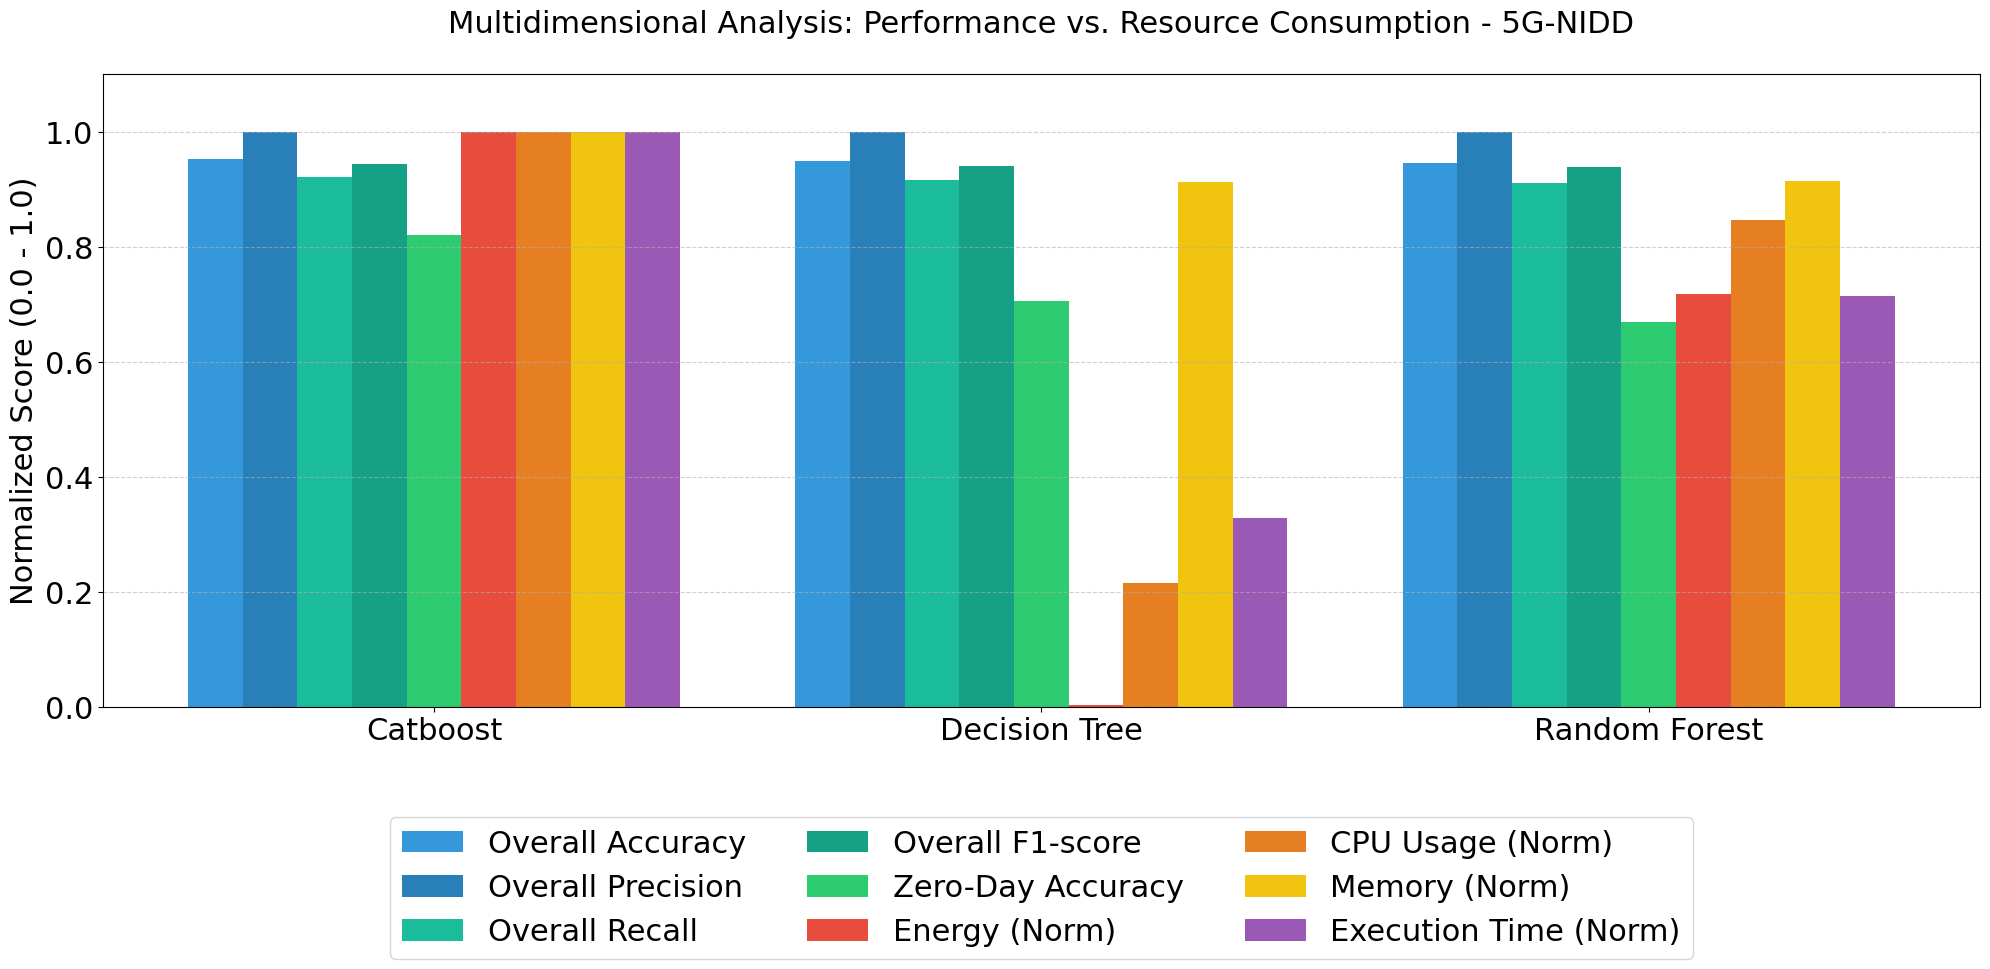

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filtrar apenas os modelos desejados
models_to_keep = ['Catboost', 'Decision Tree', 'Random Forest']
df_filtered = df[df['Model'].isin(models_to_keep)].copy()

# 2. Agrupar médias incluindo as novas métricas sugeridas
df_summary = df_filtered.groupby('Model').agg({
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall': 'mean',
    'F1': 'mean',
    'ZD - Accuracy': 'mean',
    'Energy': 'mean',
    'CPU': 'mean',
    'Memory': 'mean',
    'Time': 'mean'
}).reset_index()

# 3. Normalização (Escala 0 a 1) para métricas de custo
cols_to_norm = ['Energy', 'CPU', 'Memory', 'Time']
for col in cols_to_norm:
    df_summary[f'{col}_Norm'] = df_summary[col] / df_summary[col].max()

# 4. Configuração do Gráfico
labels = df_summary['Model'].values
x = np.arange(len(labels))
width = 0.09

fig, ax = plt.subplots(figsize=(20, 10))

# Definição de cores (Paleta harmonizada)
# Tons de azul/verde para performance | Tons quentes para custos
colors = [
    '#3498db', '#2980b9', '#1abc9c', '#16a085', '#2ecc71', # Perf (Acc, Prec, Rec, F1, ZD)
    '#e74c3c', '#e67e22', '#f1c40f', '#9b59b6'            # Custos (Energy, CPU, Mem, Time)
]

# Plotagem das 9 métricas
ax.bar(x - 4*width, df_summary['Accuracy'], width, label='Overall Accuracy', color=colors[0])
ax.bar(x - 3*width, df_summary['Precision'], width, label='Overall Precision', color=colors[1])
ax.bar(x - 2*width, df_summary['Recall'], width, label='Overall Recall', color=colors[2])
ax.bar(x - 1*width, df_summary['F1'], width, label='Overall F1-score', color=colors[3])
ax.bar(x + 0*width, df_summary['ZD - Accuracy'], width, label='Zero-Day Accuracy', color=colors[4])

ax.bar(x + 1*width, df_summary['Energy_Norm'], width, label='Energy (Norm)', color=colors[5])
ax.bar(x + 2*width, df_summary['CPU_Norm'], width, label='CPU Usage (Norm)', color=colors[6])
ax.bar(x + 3*width, df_summary['Memory_Norm'], width, label='Memory (Norm)', color=colors[7])
ax.bar(x + 4*width, df_summary['Time_Norm'], width, label='Execution Time (Norm)', color=colors[8])

# Estilização
ax.set_ylabel('Normalized Score (0.0 - 1.0)', fontsize=22)
ax.set_title('Multidimensional Analysis: Performance vs. Resource Consumption - 5G-NIDD', fontsize=22, pad=30)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=22)

# Legenda ajustada para 3 colunas para não poluir
ax.legend(fontsize=22, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.tick_params(axis='y', labelsize=22)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

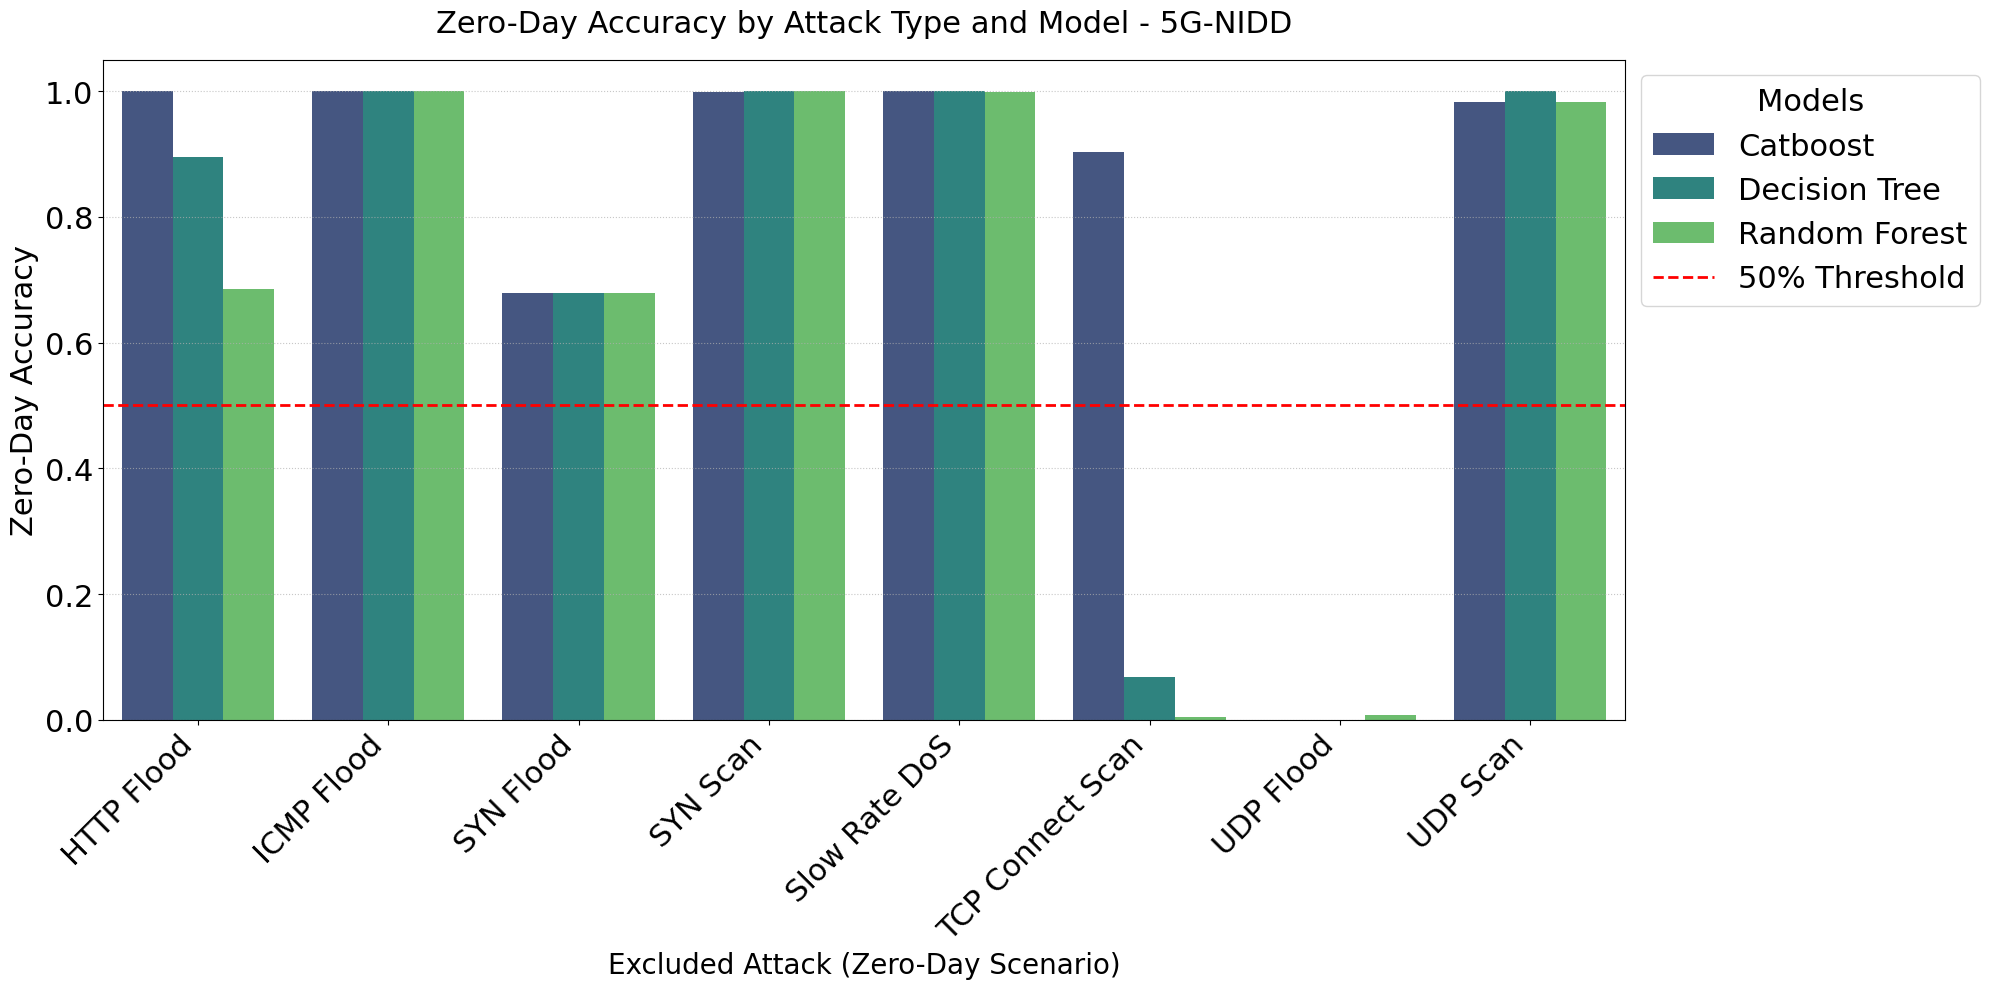

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtrar apenas os modelos baseados em árvores
models_to_keep = ['Catboost', 'Decision Tree', 'Random Forest']
df_filtered = df[df['Model'].isin(models_to_keep)].copy()

# 2. Selecionar colunas e agrupar
df_accuracy_zd = df_filtered[['Model', 'Ataque Zero-Day', 'ZD - Accuracy']]
df_plot = df_accuracy_zd.groupby(['Ataque Zero-Day', 'Model'])['ZD - Accuracy'].mean().reset_index()

# 3. Configuração do Gráfico
plt.figure(figsize=(20, 10))

# Utilizando uma paleta de cores distinta para os 3 modelos
sns.barplot(
    x='Ataque Zero-Day',
    y='ZD - Accuracy',
    hue='Model',
    data=df_plot,
    palette='viridis'
)

# Estilização de Títulos e Eixos
plt.title('Zero-Day Accuracy by Attack Type and Model - 5G-NIDD', fontsize=22, pad=20)
plt.ylabel('Zero-Day Accuracy', fontsize=22)
plt.xlabel('Excluded Attack (Zero-Day Scenario)', fontsize=20)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='50% Threshold')

# Ajuste dos ticks
plt.xticks(rotation=45, ha='right', fontsize=22)
plt.yticks(fontsize=22)

# Legenda
plt.legend(
    title='Models',
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fontsize=22,
    title_fontsize=22
)

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()